# Thesis Main Findings - E1

- **P(liked) vs. engagement (Logprobs)**:  checks whether the odds of liking a *single* post rise as its shown engagement rises. Uses `e1_results_{baseline,condition}_logprobs.json` / `_yesno_logprobs.json`. Calculated as the model's forced-choice probability of the "like"/"yes" token, averaged per engagement level.

- **Opposite-corner effect score (correct vs. incorrect)**: checks whether engagement overrides correctness, and how strongly. Uses `e1_results_{metrics,likes_only_noise}_paired.json`. For each pair of engagement levels, compares % choosing the correct post when it's the *less*-popular one vs. the *more*-popular one; score runs 0 (no effect) to 1 (engagement fully decides the outcome).

- **Engagement-magnitude by gap (correct vs. correct)**: checks whether the model follows popularity when correctness is not questionable, and whether that pull strengthens as the gap widens. Uses `e1_results_{metrics,likes_only_noise}_correct_vs_correct_paired.json`. Calculated as % choosing the higher-engagement post, averaged across pairs that sit the same number of scale-steps apart.

- **Positional bias (correct vs. correct)**: checks whether the model has a slot preference (A vs. B) independent of engagement. Uses the same correct-vs-correct file. Calculated as: rate of picking slot A when it holds the lower-engagement post, plus the rate when it holds the higher, one of these should sum to 100% if there's no bias.

- **Positional bias (correct vs. incorrect)**: same question as above, applied to the main grid. Uses `e1_results_{metrics,likes_only_noise}_paired.json`. Same sum to 100 logic, holding the engagement pair fixed and swapping which slot holds the correct post.


# Single Image Judgment

In [41]:
import json
import pandas as pd
from pathlib import Path

REPO_ROOT = next(p for p in [Path().resolve(), *Path().resolve().parents]
                  if (p / "experiments/e1").is_dir())

ROSTER = [
    ("Gemma 4 12B", "gemma4-12b"),
    ("Gemma 4 E4B", "gemma4-e4b"),
    ("Qwen3-VL-8B", "qwen3-vl-8b"),
    ("Qwen3-VL-4B", "qwen3-vl-4b"),
    ("Ministral 3 14B", "ministral-3-14b"),
    ("Ministral 3 8B", "ministral-3-8b"),
]
CONDITIONS = ["baseline", "metrics", "likes_only_noise"]


def load_records(slug, condition, yesno):
    suffix = "_yesno" if yesno else ""
    f = REPO_ROOT / "experiments/e1" / slug / "outputs" / f"e1_results_{condition}{suffix}.json"
    if not f.exists():
        return []
    return json.loads(f.read_text())


def split_by_variant(slug):
    out = {}
    for cond in CONDITIONS:
        for yesno, key, tag in [(False, "like", "Like/Scroll"), (True, "yes", "Yes/No")]:
            data = load_records(slug, cond, yesno)
            for r in data:
                out.setdefault((tag, r["variant"]), []).append(r["answer"] == key)
    return {k: round(100 * sum(v) / len(v), 1) for k, v in out.items()}


rows = []
for label, slug in ROSTER:
    default_records, yesno_records = [], []
    for cond in CONDITIONS:
        default_records += load_records(slug, cond, yesno=False)
        yesno_records += load_records(slug, cond, yesno=True)

    pct_like = 100 * sum(1 for r in default_records if r["answer"] == "like") / len(default_records) if default_records else None
    pct_yes = 100 * sum(1 for r in yesno_records if r["answer"] == "yes") / len(yesno_records) if yesno_records else None

    rows.append({
        "Model": label,
        "Like/Scroll: % chose Like": round(pct_like, 1) if pct_like is not None else None,
        "Yes/No: % chose Yes": round(pct_yes, 1) if pct_yes is not None else None,
        "n (Like/Scroll)": len(default_records),
        "n (Yes/No)": len(yesno_records),
    })

single_post_df = pd.DataFrame(rows)

qwen_scale_rows = []
for cond in ["metrics", "likes_only_noise"]:
    for yesno, key, tag in [(False, "like", "Like/Scroll"), (True, "yes", "Yes/No")]:
        data = load_records("qwen3-vl-8b", cond, yesno)
        by_scale = {}
        for r in data:
            by_scale.setdefault(r["scale_value"], []).append(r["answer"] == key)
        for scale, vals in sorted(by_scale.items()):
            qwen_scale_rows.append({
                "condition": cond,
                "phrasing": tag,
                "scale": scale,
                "pct_positive": round(100 * sum(vals) / len(vals), 1),
                "n": len(vals),
            })

qwen_scale_df = pd.DataFrame(qwen_scale_rows)

print("=== Main table ===")
display(single_post_df)

print("\n=== Correctness split, per model ===")
for label, slug in ROSTER:
    print(label, split_by_variant(slug))

# print("\n=== Qwen3-VL-8B by engagement scale ===")
# display(qwen_scale_df)

=== Main table ===


,Model,Like/Scroll: % chose Like,Yes/No: % chose Yes,n (Like/Scroll),n (Yes/No)
0,Gemma 4 12B,0.0,0.0,2600,2600
1,Gemma 4 E4B,99.6,0.0,2600,2600
2,Qwen3-VL-8B,56.7,89.0,2600,2600
3,Qwen3-VL-4B,100.0,100.0,2600,2600
4,Ministral 3 14B,100.0,99.5,2600,2600
5,Ministral 3 8B,100.0,100.0,2600,2600



=== Correctness split, per model ===
Gemma 4 12B {('Like/Scroll', 'correct'): 0.0, ('Like/Scroll', 'incorrect'): 0.0, ('Yes/No', 'correct'): 0.0, ('Yes/No', 'incorrect'): 0.0}
Gemma 4 E4B {('Like/Scroll', 'correct'): 99.7, ('Like/Scroll', 'incorrect'): 99.5, ('Yes/No', 'correct'): 0.0, ('Yes/No', 'incorrect'): 0.0}
Qwen3-VL-8B {('Like/Scroll', 'correct'): 71.5, ('Like/Scroll', 'incorrect'): 41.8, ('Yes/No', 'correct'): 93.1, ('Yes/No', 'incorrect'): 84.8}
Qwen3-VL-4B {('Like/Scroll', 'correct'): 99.9, ('Like/Scroll', 'incorrect'): 100.0, ('Yes/No', 'correct'): 100.0, ('Yes/No', 'incorrect'): 100.0}
Ministral 3 14B {('Like/Scroll', 'correct'): 100.0, ('Like/Scroll', 'incorrect'): 100.0, ('Yes/No', 'correct'): 99.1, ('Yes/No', 'incorrect'): 100.0}
Ministral 3 8B {('Like/Scroll', 'correct'): 100.0, ('Like/Scroll', 'incorrect'): 100.0, ('Yes/No', 'correct'): 100.0, ('Yes/No', 'incorrect'): 100.0}


# Logprobs Analysis

In [42]:
import json
from pathlib import Path
from collections import defaultdict

REPO_ROOT = next(p for p in [Path().resolve(), *Path().resolve().parents]
                 if (p / "experiments/e1").is_dir())

ROSTER = [("Gemma 4 12B", "gemma4-12b"), ("Qwen3-VL-8B", "qwen3-vl-8b"),
          ("Ministral 3 14B", "ministral-3-14b"), ("Gemma 4 E4B", "gemma4-e4b"),
          ("Qwen3-VL-4B", "qwen3-vl-4b"), ("Ministral 3 8B", "ministral-3-8b")]

SCALES = [0, 10, 100, 1000, 10000, 100000, 1000000]
LABELS = ["0", "10", "100", "1K", "10K", "100K", "1M"]

# phrasing -> (which candidate counts as "liked", filename template)
PHRASING = {"like/scroll": ("like", "e1_results_{c}_logprobs.json"),
            "yes/no":      ("yes",  "e1_results_{c}_yesno_logprobs.json")}


def p_liked(slug, phrasing, condition):
    """Mean P(liked) per variant per engagement level.

    P is `prob_forced_choice` — the model's probability of the liking token *renormalised
    against its opposite*, so it answers "given it had to pick one, how far toward liking
    was it?" rather than being diluted by every other token in the vocabulary.

    Scale 0 comes from the baseline run (no engagement shown); 10..1M from `condition`.
    """
    key, pat = PHRASING[phrasing]
    acc = defaultdict(lambda: defaultdict(list))
    for c in ("baseline", condition):
        f = REPO_ROOT / "experiments/e1" / slug / "outputs" / pat.format(c=c)
        if not f.exists():
            print(f"  ⚠ missing: {f.relative_to(REPO_ROOT)}")
            continue
        for r in json.loads(f.read_text()):
            p = r.get("candidates", {}).get(key, {}).get("prob_forced_choice")
            if p is not None:
                acc[r["variant"]][r.get("scale_value", 0)].append(p)
    return {v: {s: sum(ps) / len(ps) for s, ps in sc.items()} for v, sc in acc.items()}


print(f"root: {REPO_ROOT}\n{len(ROSTER)} models")

root: /home/jovyan/conformity-llms-facebook-posts
6 models


# Likes only 

/tmp/ipykernel_665/2737623924.py:26: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


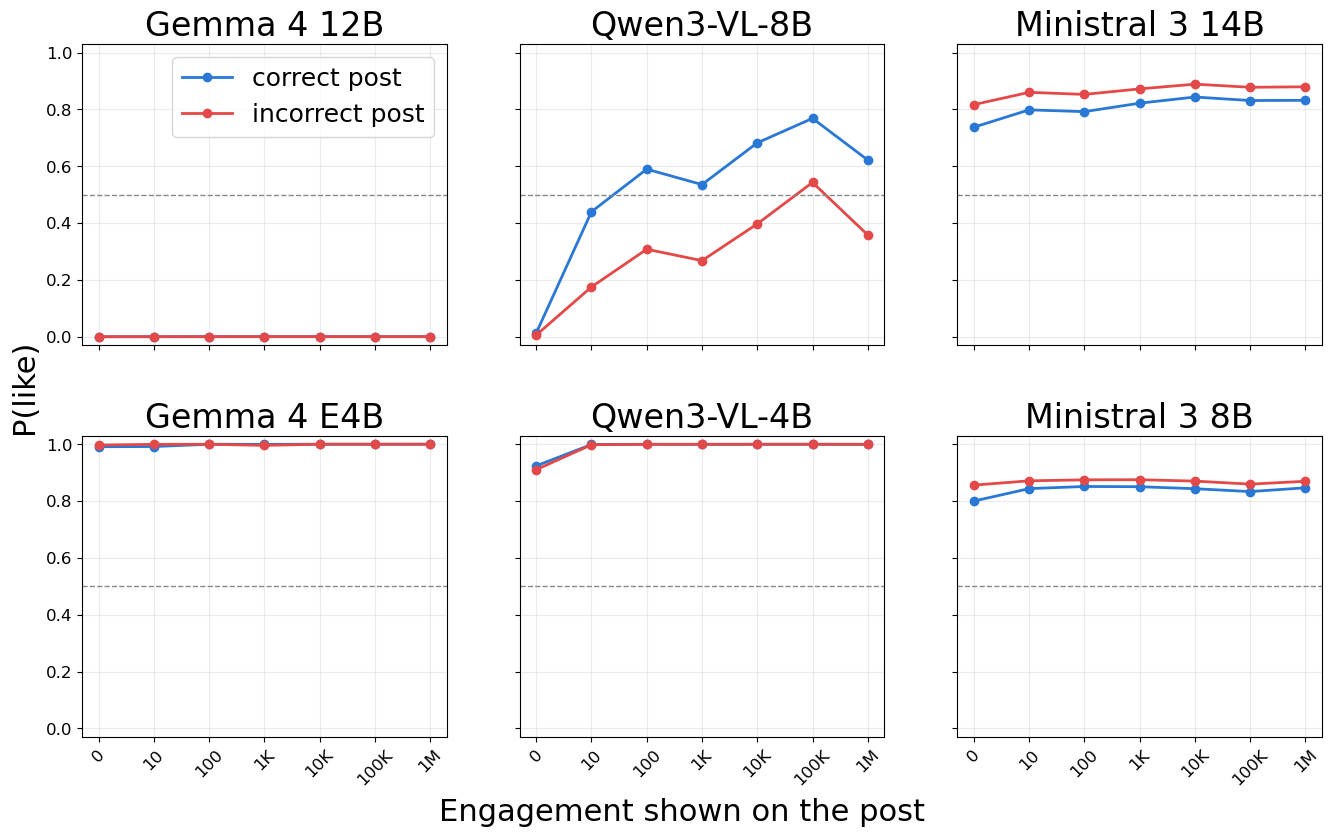

/tmp/ipykernel_665/2737623924.py:26: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


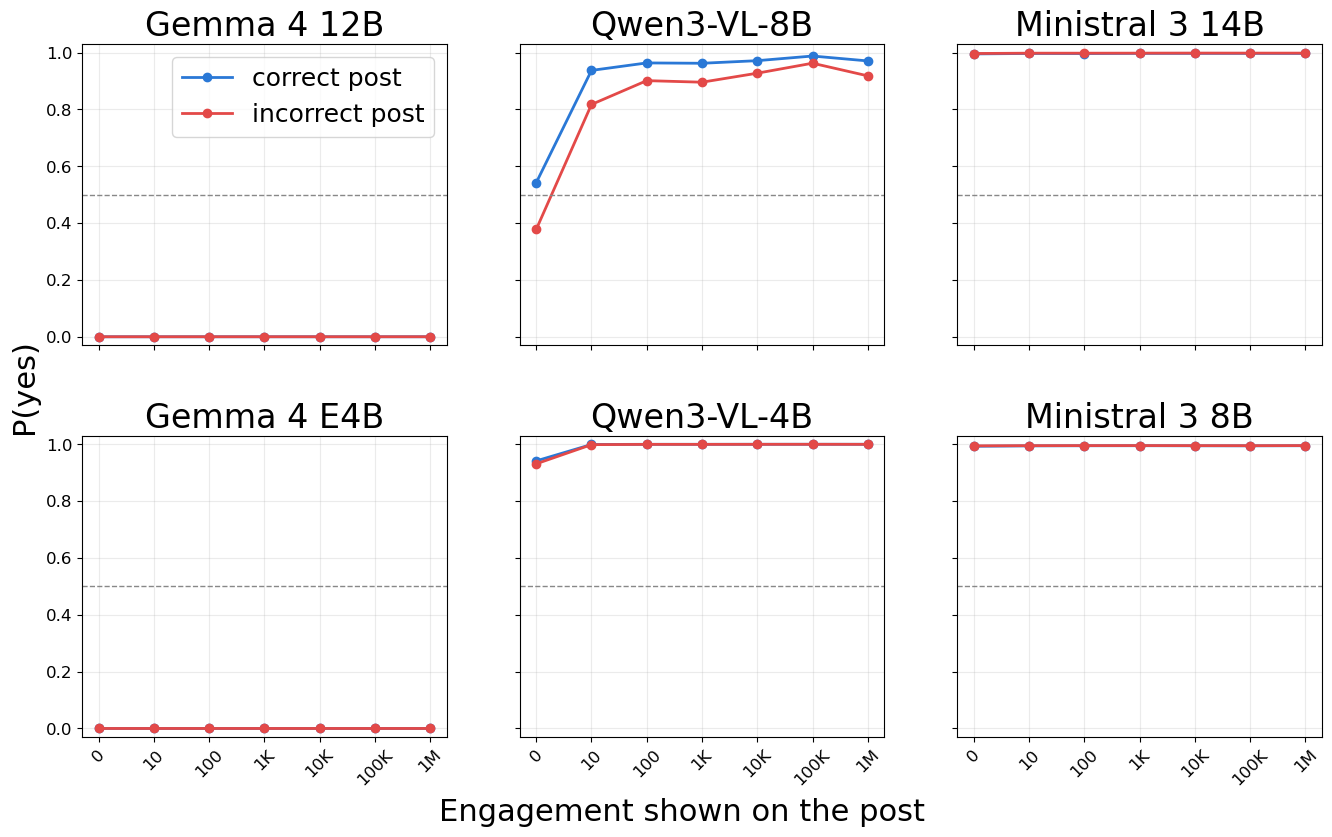

In [50]:
import matplotlib.pyplot as plt

def plot_engagement_curve(phrasing="like/scroll", condition="likes_only_noise", logy=False):
    fig, axes = plt.subplots(2, 3, figsize=(16, 9), sharex=True, sharey=not logy, gridspec_kw={"hspace": 0.3})
    for ax, (label, slug) in zip(axes.flatten(), ROSTER):
        d = p_liked(slug, phrasing, condition)
        for variant, colour in (("correct", "#2a78d6"), ("incorrect", "#e34948")):
            pts = [(i, d[variant][s]) for i, s in enumerate(SCALES) if s in d.get(variant, {})]
            if pts:
                ax.plot([x for x, _ in pts], [y for _, y in pts],
                        marker="o", lw=2, color=colour, label=f"{variant} post")
        ax.set_title(label, fontsize=24)
        ax.set_xticks(range(len(SCALES)))
        ax.set_xticklabels(LABELS, fontsize=12, rotation=45)
        ax.tick_params(axis='y', labelsize=12)
        ax.grid(alpha=0.25)
        if logy:
            ax.set_yscale("log")
        else:
            ax.set_ylim(-0.03, 1.03)
            ax.axhline(0.5, ls="--", color="#888888", lw=1)
    axes.flatten()[0].legend(fontsize=18)
    fig.supxlabel("Engagement shown on the post", fontsize=22, y=0.01)
    fig.supylabel(f"P({PHRASING[phrasing][0]})", fontsize=22, x=0.08 )
    #fig.suptitle(f"Does displayed engagement raise the probability of liking?  —  " f"{phrasing}, {condition}" + ("   [log scale]" if logy else ""), fontsize=18, fontweight="bold", y=1.01)
    plt.tight_layout()
    safe_phrasing = phrasing.replace("/", "-")
    fig.savefig(f"engagement_{safe_phrasing}_{condition}.png", dpi=300, bbox_inches="tight")
    plt.show()


plot_engagement_curve("like/scroll", "likes_only_noise")
plot_engagement_curve("yes/no", "likes_only_noise")

# Metrics

/tmp/ipykernel_665/3773614382.py:24: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


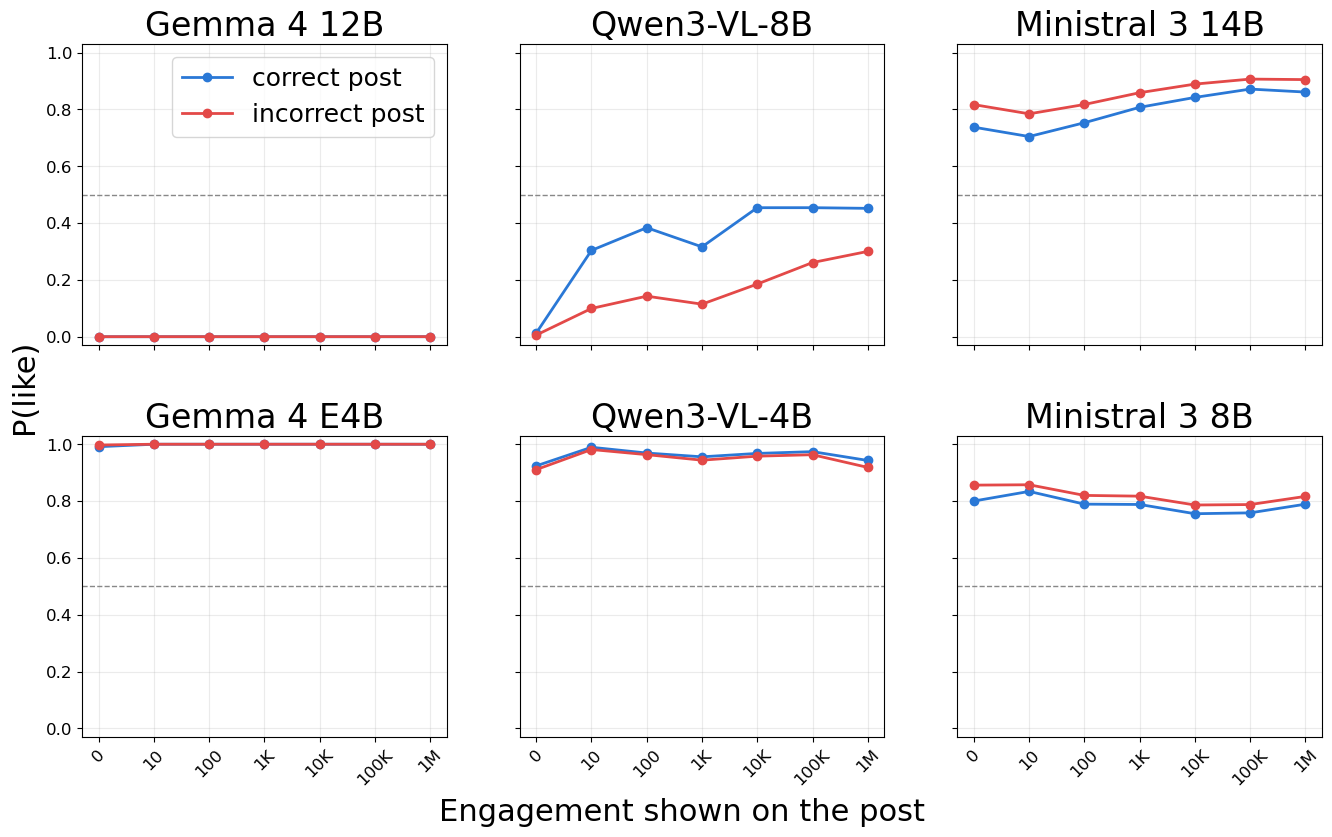

/tmp/ipykernel_665/3773614382.py:24: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


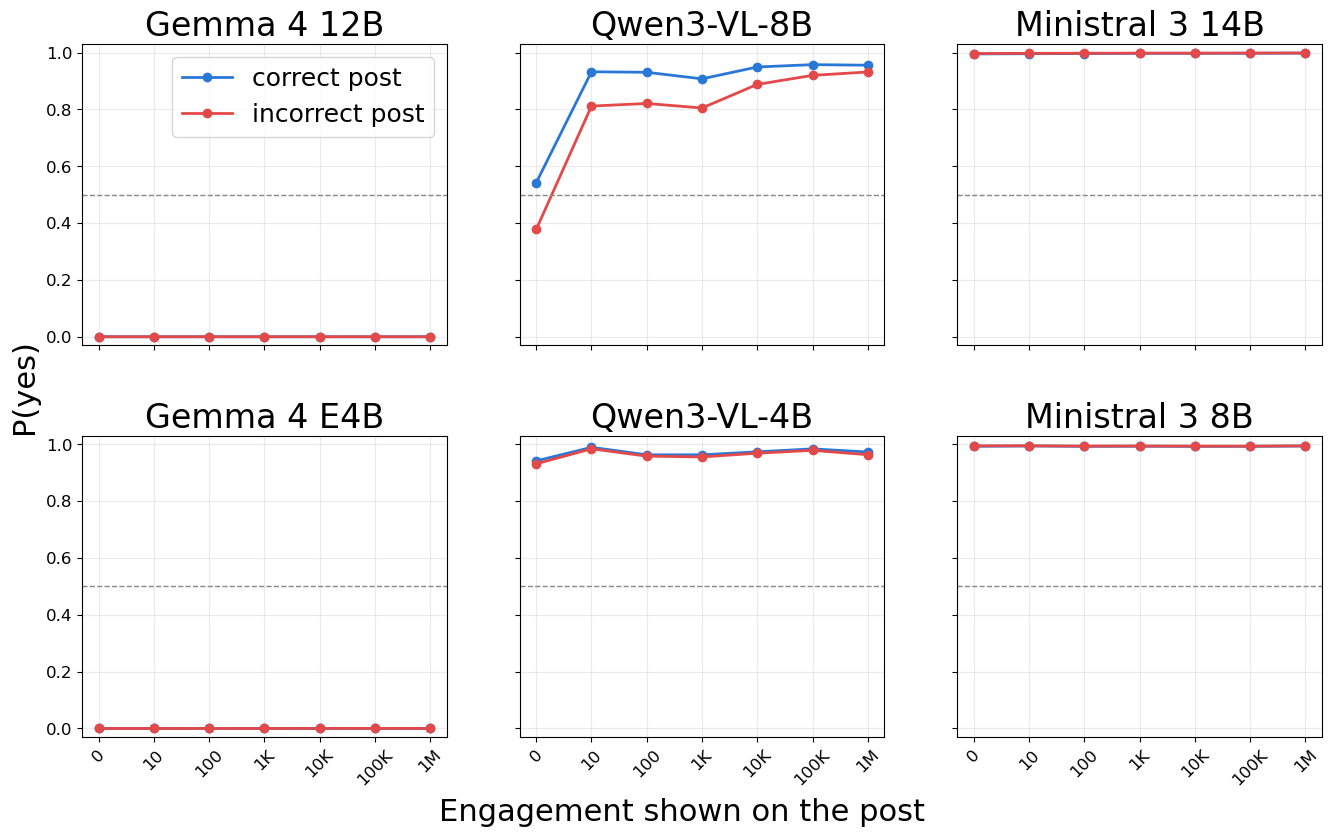

In [47]:
def plot_engagement_curve(phrasing="like/scroll", condition="metrics", logy=False):
    fig, axes = plt.subplots(2, 3, figsize=(16, 9), sharex=True, sharey=not logy, gridspec_kw={"hspace": 0.3})
    for ax, (label, slug) in zip(axes.flatten(), ROSTER):
        d = p_liked(slug, phrasing, condition)
        for variant, colour in (("correct", "#2a78d6"), ("incorrect", "#e34948")):
            pts = [(i, d[variant][s]) for i, s in enumerate(SCALES) if s in d.get(variant, {})]
            if pts:
                ax.plot([x for x, _ in pts], [y for _, y in pts],
                        marker="o", lw=2, color=colour, label=f"{variant} post")
        ax.set_title(label, fontsize=24)
        ax.set_xticks(range(len(SCALES)))
        ax.set_xticklabels(LABELS, fontsize=12, rotation=45)
        ax.tick_params(axis='y', labelsize=12)
        ax.grid(alpha=0.25)
        if logy:
            ax.set_yscale("log")
        else:
            ax.set_ylim(-0.03, 1.03)
            ax.axhline(0.5, ls="--", color="#888888", lw=1)
    axes.flatten()[0].legend(fontsize=18)
    fig.supxlabel("Engagement shown on the post", fontsize=22, y=0.01)
    fig.supylabel(f"P({PHRASING[phrasing][0]})", fontsize=22, x=0.08 )
    #fig.suptitle(f"Does displayed engagement raise the probability of liking?  —  " f"{phrasing}, {condition}" + ("   [log scale]" if logy else ""), fontsize=18, fontweight="bold", y=1.01)
    plt.tight_layout()
    safe_phrasing = phrasing.replace("/", "-")
    fig.savefig(f"engagement_{safe_phrasing}_{condition}.png", dpi=300, bbox_inches="tight")
    plt.show()



plot_engagement_curve("like/scroll", "metrics")
plot_engagement_curve("yes/no", "metrics")

In [6]:
for phrasing in ("like/scroll", "yes/no"):
    for condition in ("metrics", "likes_only_noise"):
        print(f"\n{'='*100}\nP({PHRASING[phrasing][0]}) — {phrasing}, {condition}\n{'='*100}")
        print(f"{'model':17s}{'variant':11s}" + "".join(f"{l:>10s}" for l in LABELS) + "     0→1M")
        for label, slug in ROSTER:
            d = p_liked(slug, phrasing, condition)
            for variant in ("correct", "incorrect"):
                row = d.get(variant, {})
                cells = "".join(f"{row[s]:9.3f} " if s in row else "        - " for s in SCALES)
                delta = (f"{row[SCALES[-1]] - row[0]:+7.3f}"
                         if SCALES[0] in row and SCALES[-1] in row else "      -")
                print(f"{label:17s}{variant:11s}{cells}{delta}")
            print()


P(like) — like/scroll, metrics
model            variant             0        10       100        1K       10K      100K        1M     0→1M
Gemma 4 12B      correct        0.000     0.000     0.000     0.000     0.000     0.000     0.000  +0.000
Gemma 4 12B      incorrect      0.000     0.000     0.000     0.000     0.000     0.000     0.000  +0.000

Qwen3-VL-8B      correct        0.013     0.304     0.384     0.316     0.454     0.454     0.452  +0.439
Qwen3-VL-8B      incorrect      0.006     0.100     0.143     0.115     0.185     0.261     0.300  +0.294

Ministral 3 14B  correct        0.737     0.704     0.753     0.807     0.842     0.871     0.861  +0.124
Ministral 3 14B  incorrect      0.817     0.784     0.817     0.859     0.889     0.907     0.905  +0.088

Gemma 4 E4B      correct        0.991     1.000     1.000     1.000     1.000     1.000     1.000  +0.009
Gemma 4 E4B      incorrect      0.997     1.000     1.000     1.000     1.000     1.000     1.000  +0.003

Qwen3-VL

# Opposite-corner ratio test. Correct vs. incorrect

Calculate an Effect Score as 1 - (disadvantaged / advantaged).
"Advantaged" cells are where the correct answer has high likes (lower right of the grids).

- No effect: Model scores 90% in both scenarios. 1 - (90/90) = 0.
- Extreme effect: Model drops to 0% when disadvantaged. 1 - (0/90) = 1.0.

In [7]:
GRID_CONDITIONS = ["likes_only_noise", "metrics"]

def load_paired_grid(slug, condition):
    """Load one model's correct-vs-incorrect A/B grid (7x7 scales x 100 images)."""
    f = REPO_ROOT / "experiments/e1" / slug / "outputs" / f"e1_results_{condition}_paired.json"
    if not f.exists():
        print(f"  ⚠ missing: {f.relative_to(REPO_ROOT)}")
        return {}
    grid = defaultdict(list)
    for r in json.loads(f.read_text()):
        grid[(r["correct_scale"], r["incorrect_scale"])].append(r["liked_variant"] == "correct")
    return grid

def cell_pct(grid, cs, ics):
    """Raw % choosing correct at one grid cell."""
    vals = grid.get((cs, ics))
    if not vals:
        return None
    n, k = len(vals), sum(vals)
    return {"n": n, "k": k, "pct": 100 * k / n}

def opposite_corner_ratios(slug, condition):
    """
    Calculates a Conformity Effect Score: 1 - (disadvantaged / advantaged).
    Score -> 0.0: No conformity effect (engagement makes no difference).
    Score -> 1.0: Maximum conformity (model is entirely manipulated).

    Both percentages get a Haldane-Anscombe continuity correction ((k+0.5)/(n+1)) before
    dividing -- not because advantaged_pct ever actually hits 0 in this data (checked: it
    doesn't, across all 252 pairs), but because a raw 0% cell is still a small-sample point
    estimate, and the correction is the standard, defensible way to report it.
    """
    grid = load_paired_grid(slug, condition)
    rows = []
    for cs in SCALES:
        for ics in SCALES:
            if cs >= ics:
                continue
            disadv = cell_pct(grid, cs, ics)   # correct=X (small), incorrect=Y (large)
            adv = cell_pct(grid, ics, cs)      # correct=Y (large), incorrect=X (small)
            if disadv is None or adv is None:
                continue
            
            # 1 - (disadvantaged / advantaged). Safe division because 'adv' is rarely/never 0.
            effect_score = 1.0 - (disadv["pct"] / adv["pct"]) if adv["pct"] > 0 else 0.0
            
            rows.append({
                "correct_scale_disadv": cs, "incorrect_scale_disadv": ics,
                "disadvantaged_pct": disadv["pct"], "advantaged_pct": adv["pct"],
                "effect_score": effect_score,
            })
    return rows

results = []
for label, slug in ROSTER:
    for condition in GRID_CONDITIONS:
        rows = opposite_corner_ratios(slug, condition)
        if not rows:
            continue
        mean_effect = sum(r["effect_score"] for r in rows) / len(rows)
        extreme_effect = next((r["effect_score"] for r in rows
                         if r["correct_scale_disadv"] == SCALES[0] and r["incorrect_scale_disadv"] == SCALES[-1]), None)
        results.append((label, condition, mean_effect, extreme_effect))

# Sort descending so the HIGHEST conformity effect (closest to 1.0) is at the top
results.sort(key=lambda r: (r[3] is None, -r[3] if r[3] is not None else 0))
'''
print(f"\n{'='*70}\nOpposite-corner effect score — correct vs. incorrect (both conditions)\n{'='*70}")
print(f"{'model':17s}{'condition':17s}{'mean effect (0=none)':>24s}{'extreme effect (0=none)':>26s}")
for label, condition, mean_effect, extreme_effect in results:
    extreme_str = f"{extreme_effect:.4f}" if extreme_effect is not None else "-"
    print(f"{label:17s}{condition:17s}{mean_effect:24.4f}{extreme_str:>26s}")
'''

'\nprint(f"\n{\'=\'*70}\nOpposite-corner effect score — correct vs. incorrect (both conditions)\n{\'=\'*70}")\nprint(f"{\'model\':17s}{\'condition\':17s}{\'mean effect (0=none)\':>24s}{\'extreme effect (0=none)\':>26s}")\nfor label, condition, mean_effect, extreme_effect in results:\n    extreme_str = f"{extreme_effect:.4f}" if extreme_effect is not None else "-"\n    print(f"{label:17s}{condition:17s}{mean_effect:24.4f}{extreme_str:>26s}")\n'

In [8]:
# Choose which condition to display: "metrics" OR "likes_only_noise"
TARGET_CONDITION = "metrics"

# 1. Filter the results for the chosen condition
filtered_results = [r for r in results if r[1] == TARGET_CONDITION]

# 2. Sort the filtered results by Mean Effect (highest conformity first)
# r[2] is the mean_effect. We use -r[2] to sort descending (closest to 1.0 at the top).
filtered_results.sort(key=lambda r: -r[2])

print(f"\n--- FILTERED RESULTS: {TARGET_CONDITION.upper()} ---")
print(f"{'model':17s}{'condition':17s}{'mean effect (0=none)':>24s}{'extreme effect (0=none)':>26s}")

for label, condition, mean_effect, extreme_effect in filtered_results:
    extreme_str = f"{extreme_effect:.4f}" if extreme_effect is not None else "-"
    print(f"{label:17s}{condition:17s}{mean_effect:24.4f}{extreme_str:>26s}")


TARGET_CONDITION = "likes_only_noise"
filtered_results = [r for r in results if r[1] == TARGET_CONDITION]
filtered_results.sort(key=lambda r: -r[2])

print(f"\n--- FILTERED RESULTS: {TARGET_CONDITION.upper()} ---")
print(f"{'model':17s}{'condition':17s}{'mean effect (0=none)':>24s}{'extreme effect (0=none)':>26s}")

for label, condition, mean_effect, extreme_effect in filtered_results:
    extreme_str = f"{extreme_effect:.4f}" if extreme_effect is not None else "-"
    print(f"{label:17s}{condition:17s}{mean_effect:24.4f}{extreme_str:>26s}")


--- FILTERED RESULTS: METRICS ---
model            condition            mean effect (0=none)   extreme effect (0=none)
Ministral 3 14B  metrics                            1.0000                    1.0000
Gemma 4 E4B      metrics                            0.9880                    1.0000
Qwen3-VL-8B      metrics                            0.9825                    1.0000
Ministral 3 8B   metrics                            0.9343                    0.9880
Qwen3-VL-4B      metrics                            0.8776                    1.0000
Gemma 4 12B      metrics                            0.0582                    0.1684

--- FILTERED RESULTS: LIKES_ONLY_NOISE ---
model            condition            mean effect (0=none)   extreme effect (0=none)
Qwen3-VL-4B      likes_only_noise                   0.9496                    0.9897
Ministral 3 14B  likes_only_noise                   0.9471                    1.0000
Gemma 4 E4B      likes_only_noise                   0.8388             

# Correct vs. correct

We already know that "higher always wins." I now want to investigate whether there is a bigger jump depending on the difference between engagement metrics or not.

A single pair's rate (say, 10 vs 100) already tells us whether higher win at that specific gap size. My next question here is: does the preference need a big gap to kick in, or does any visible difference already max it out?

- This condition has zero correctness signal to resist since both posts say the same true thing, so there's nothing for the model to weigh against engagement.

**What we're calculating**:  
- There are 7 engagement levels (0, 10, 100, ..., 1M). "Gap" just means how many steps apart two levels are on that list 

- A gap of 1 means neighbors: 0-vs-10, 10-vs-100, 100-vs-1000, and so on. 6 such neighbor pairs exist. A gap of 6 means the two ends of the list, 0-vs-1M, only 1 pair can be that far apart. In between, gap=2 has 5 pairs, gap=3 has 4, gap=4 has 3, gap=5 has 2.

- Add them up 6+5+4+3+2+1 and you get 21, the total number of unique pairs possible from 7 points. That's the same 21 pairs used everywhere else in this analysis.


In [9]:
def load_cvc_grid(slug, condition):
    """Load one model's correct-vs-correct control grid (7x7 scales x 100 images).

    Both posts carry the correct claim, so there's no "correct"/"incorrect" identity to
    disadvantage the way the main grid has -- post A/B are arbitrary slots. Pairs are pooled
    by the *unordered* scale pair {scale_a, scale_b}, merging both slot assignments, so the
    result measures "does the bigger number win" independent of which side it's on.

    Returns {frozenset({scale_a, scale_b}): [liked_higher_engagement: bool, ...]}.
    """
    f = REPO_ROOT / "experiments/e1" / slug / "outputs" / f"e1_results_{condition}_correct_vs_correct_paired.json"
    if not f.exists():
        print(f"  ⚠ missing: {f.relative_to(REPO_ROOT)}")
        return {}
    grid = defaultdict(list)
    for r in json.loads(f.read_text()):
        pair = frozenset({r["scale_a"], r["scale_b"]})
        if len(pair) < 2:
            continue  # tied scale -- no "higher" post, not part of the 21 off-diagonal pairs
        grid[pair].append(bool(r["liked_higher_engagement"]))
    return grid


def cvc_pair_rate(grid, x, y):
    """% choosing the higher-engagement post at one pooled (X, Y) pair, both slots merged.

    Raw percentage, no continuity correction -- there's no division here (just a single
    rate), so there's nothing for the correction to protect against, and it would only add
    an unnecessary small distortion. Same reasoning applies to every other rate function
    in this notebook; only the opposite-corner *ratio* would ever need it, and that one
    never hits a zero denominator either (checked across all 252 pairs).
    """
    vals = grid.get(frozenset({x, y}))
    if not vals:
        return None
    n, k = len(vals), sum(vals)
    return {"n": n, "pct": 100 * k / n}


def rates_by_gap(slug, condition):
    """Rate of choosing the higher-engagement post, averaged across all pairs that are the
    same number of scale-steps apart (gap=1: adjacent scales, e.g. 10 vs 100; gap=6: the full
    range, 0 vs 1M). Shows whether the preference climbs gradually with gap size or is already
    near-ceiling even at the smallest visible difference.
    """
    grid = load_cvc_grid(slug, condition)
    by_gap = defaultdict(list)
    for i, cs in enumerate(SCALES):
        for j, ics in enumerate(SCALES):
            if i >= j:
                continue
            r = cvc_pair_rate(grid, cs, ics)
            if r is not None:
                by_gap[j - i].append(r["pct"])
    return {gap: sum(vals) / len(vals) for gap, vals in by_gap.items()}

'''
for condition in GRID_CONDITIONS:
    print(f"\n{'='*80}\n{condition}  —  % choosing higher-engagement post, by gap size (in scale-steps)\n{'='*80}")
    print(f"{'model':17s}" + "".join(f"gap={g:<8d}" for g in range(1, 7)))
    for label, slug in ROSTER:
        rates = rates_by_gap(slug, condition)
        row = "".join(f"{rates.get(g, float('nan')):8.2f} " for g in range(1, 7))
        print(f"{label:17s}{row}")

'''

'\nfor condition in GRID_CONDITIONS:\n    print(f"\n{\'=\'*80}\n{condition}  —  % choosing higher-engagement post, by gap size (in scale-steps)\n{\'=\'*80}")\n    print(f"{\'model\':17s}" + "".join(f"gap={g:<8d}" for g in range(1, 7)))\n    for label, slug in ROSTER:\n        rates = rates_by_gap(slug, condition)\n        row = "".join(f"{rates.get(g, float(\'nan\')):8.2f} " for g in range(1, 7))\n        print(f"{label:17s}{row}")\n\n'

Stands out: 
- Gemma-E4B under likes_only_noise: 81.76 → 75.97 → 92.91 → 98.26 → 96.27 → 99.75. It dips once (gap=1 to gap=2), then climbs the rest of the way — ending higher than it started, not lower.
- Same shape for Ministral-3-14B (86.48 → 80.95 → ... → 99.75) and
- Ministral-3-8B (89.22 → ... → 99.75).

None of the twelve rows end lower than they start. So the actual pattern is a small dip early, then a rise.

What the number itself means, concretely: each cell is "out of all trials where the two posts' engagement levels were this many scale-steps apart, what % of the time did the model pick the one with more?" So a higher gap = the two engagement numbers are further apart (easier to tell which is bigger) — and a rising value as gap increases means the model's pull toward the bigger number gets stronger as the difference between the two grows. That's the expected, intuitive direction: a huge gap (0 vs 1,000,000) should pull harder than a small one (10 vs 100), and for most rows it does.

gap=1 isn't simply "the baseline" either: gap=1 pools 6 different pairs (10-vs-100, 100-vs-1000, etc.), while gap=6 is just one pair (0-vs-1M) — there's less averaging at the high end, which is part of why the far-right column matches the earlier "extreme" number exactly.


higher gap number → stronger pull toward the bigger-engagement post, for every model — with a common exception where gap=2 dips slightly below gap=1 before climbing again.


In [10]:
gap_summary = []
for condition in GRID_CONDITIONS:
    for label, slug in ROSTER:
        rates = rates_by_gap(slug, condition)
        if 1 not in rates or 6 not in rates:
            continue
        gap_summary.append((label, condition, rates[1], rates[6], rates[6] - rates[1]))

gap_summary.sort(key=lambda r: -r[4])  # biggest climb (most gap-size-dependent) first

print(f"\n{'='*70}\nEngagement-magnitude climb (gap=1 to gap=6) — correct vs. correct\n{'='*70}")
print(f"{'model':17s}{'condition':17s}{'gap=1 %':>10s}{'gap=6 %':>10s}{'climb (6-1)':>14s}")
for label, condition, g1, g6, climb in gap_summary:
    print(f"{label:17s}{condition:17s}{g1:10.2f}{g6:10.2f}{climb:14.2f}")


Engagement-magnitude climb (gap=1 to gap=6) — correct vs. correct
model            condition           gap=1 %   gap=6 %   climb (6-1)
Gemma 4 E4B      likes_only_noise      81.92    100.00         18.08
Ministral 3 14B  likes_only_noise      86.67    100.00         13.33
Ministral 3 8B   likes_only_noise      89.42    100.00         10.58
Gemma 4 12B      metrics               93.75     97.00          3.25
Qwen3-VL-4B      metrics               97.42    100.00          2.58
Qwen3-VL-8B      likes_only_noise      98.17    100.00          1.83
Qwen3-VL-4B      likes_only_noise      99.50    100.00          0.50
Ministral 3 14B  metrics               99.67    100.00          0.33
Gemma 4 E4B      metrics               99.83    100.00          0.17
Gemma 4 12B      likes_only_noise      99.42     99.50          0.08
Qwen3-VL-8B      metrics              100.00    100.00          0.00
Ministral 3 8B   metrics              100.00    100.00          0.00


In [11]:
def gap_deltas(slug, condition):
    """Change in %-choosing-higher-engagement from one gap size to the next
    (gap 1->2, 2->3, ..., 5->6). Positive = preference strengthens at that step;
    negative = it weakens. Easier to scan than the raw rates, which all sit in a
    narrow 75-100% band and make small moves hard to spot.
    """
    rates = rates_by_gap(slug, condition)
    return {d: rates[d + 1] - rates[d] for d in range(1, 6) if d in rates and d + 1 in rates}


for condition in GRID_CONDITIONS:
    print(f"\n{'='*80}\n{condition}  —  change in % choosing higher-engagement, gap to gap\n{'='*80}")
    labels = [f"{d}->{d+1}" for d in range(1, 6)]
    print(f"{'model':17s}" + "".join(f"{l:>9s}" for l in labels))
    for label, slug in ROSTER:
        deltas = gap_deltas(slug, condition)
        row = "".join(f"{deltas.get(d, float('nan')):+9.2f}" for d in range(1, 6))
        print(f"{label:17s}{row}")


likes_only_noise  —  change in % choosing higher-engagement, gap to gap
model                 1->2     2->3     3->4     4->5     5->6
Gemma 4 12B          -0.32    -0.47    +0.38    +0.50    +0.00
Qwen3-VL-8B         -14.77    +5.47   +11.12    -0.75    +0.75
Ministral 3 14B      -5.57   +10.53    -4.12    +6.25    +6.25
Gemma 4 E4B          -5.82   +17.03    +5.38    -2.00    +3.50
Qwen3-VL-4B          -5.70    +5.08    +1.12    +0.00    +0.00
Ministral 3 8B       +9.48    -0.15    +1.08    +0.17    +0.00

metrics  —  change in % choosing higher-engagement, gap to gap
model                 1->2     2->3     3->4     4->5     5->6
Gemma 4 12B          -3.05    -1.45    +1.75    +2.50    +3.50
Qwen3-VL-8B          -0.10    +0.10    +0.00    +0.00    +0.00
Ministral 3 14B      +0.03    -0.08    +0.04    +0.33    +0.00
Gemma 4 E4B          -3.43    +3.35    +0.25    +0.00    +0.00
Qwen3-VL-4B          -0.12    -5.42    +8.12    +0.00    +0.00
Ministral 3 8B       +0.00    +0.00    +0.00

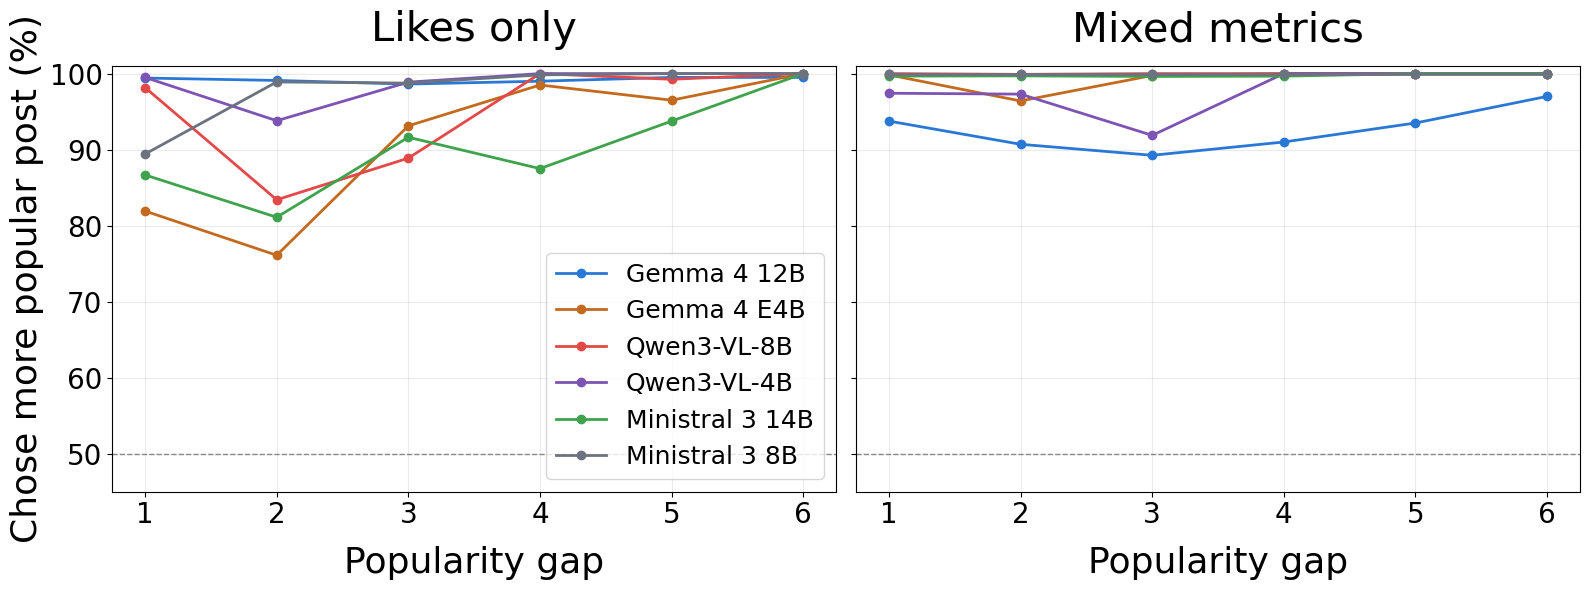

In [34]:
MODEL_COLORS = {
    "gemma4-12b":      "#2a78d6",
    "qwen3-vl-8b":     "#e34948",
    "ministral-3-14b": "#3fa34d",
    "gemma4-e4b":      "#c46a1f",
    "qwen3-vl-4b":     "#7d54b3",
    "ministral-3-8b":  "#6b7280",
}

ROSTER_BY_FAMILY = [("Gemma 4 12B", "gemma4-12b"), ("Gemma 4 E4B", "gemma4-e4b"), ("Qwen3-VL-8B", "qwen3-vl-8b"),("Qwen3-VL-4B", "qwen3-vl-4b"), 
                    ("Ministral 3 14B", "ministral-3-14b"),("Ministral 3 8B", "ministral-3-8b")]

CONDITION_TITLES = {
    "metrics": "Mixed metrics",
    "likes_only_noise": "Likes only",
}

def plot_gap_rates():
    fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)
    for ax, condition in zip(axes, GRID_CONDITIONS):
        for label, slug in ROSTER_BY_FAMILY:
            rates = rates_by_gap(slug, condition)
            xs = [d for d in range(1, 7) if d in rates]
            ys = [rates[d] for d in xs]
            ax.plot(xs, ys, marker="o", lw=2, color=MODEL_COLORS[slug], label=label)
        ax.axhline(50, ls="--", color="#888888", lw=1)  # label="no preference (50%)"
        ax.set_xticks(range(1, 7))
        ax.set_xticklabels(range(1, 7), fontsize=20)
        ax.tick_params(axis="y", labelsize=20)
        ax.set_title(CONDITION_TITLES.get(condition, condition), fontsize=30, pad=18)
        ax.set_xlabel("Popularity gap", fontsize=26, labelpad=12)
        ax.set_ylim(45, 101)
        ax.grid(alpha=0.25)
    axes[0].set_ylabel("Chose more popular post (%)", fontsize=26)
    axes[0].legend(fontsize=18, loc="lower right")
    plt.tight_layout()
    plt.savefig("popularity-gap-effect.png", dpi=300, bbox_inches="tight")
    plt.show()

plot_gap_rates()

**Even the smallest gap in the grid (10 vs 100, a 10× difference) is already enough to make the model pick the higher-engagement post almost every single time. The gap size beyond that point barely matters.**

Gemma-12B is the one exception worth naming: 91.9% mean vs 97.0% extreme under metrics. That's a real, if modest, gap between the two — meaning small differences move it less than large ones. Its preference is somewhat graded rather than an on/off switch, consistent with it being the one model elsewhere in this study that shows genuine judgment rather than reflexive engagement-following.

Correct vs. correct is the ceiling case and reading it alongside the correct-vs-incorrect table tells you whether a model's conformity there is "engagement is a powerful cue that overrides correctness" (consistent with near-100% here too) versus something stranger, like a model that only responds to engagement when correctness is also in play. What we actually see is the confirmation: engagement-following is close to universal and near-instant once any signal exists, for every model except Gemma-12B. 



## Diagonal analysis: positional/primary bias in most of the models

Was A always shown before B? Yes, always."Post A:" + image, then "Post B:" + image, in that fixed order, every single trial. What's randomized (rng.random() < 0.5) is only which content, correct or incorrect,  gets slotted into the "Post A" (shown first) position versus "Post B". The presentation order itself never varies. And because it never varies we can say that there is a bias towards liking A or B, because they stay constant throughout.


In [13]:
def diagonal_accuracy_by_slot(slug, condition):
    """Diagonal accuracy (zero engagement disparity), split by which slot held the correct
    post, plus a single pooled number combining both slots. If a model reads content rather
    than defaulting to a fixed slot, the two split numbers should be close to each other --
    a large gap means the model is answering by position, not content, on the diagonal
    specifically, and the pooled number should then be read with that caveat rather than as
    a clean competence score.
    """
    f = REPO_ROOT / "experiments/e1" / slug / "outputs" / f"e1_results_{condition}_paired.json"
    if not f.exists():
        print(f"  ⚠ missing: {f.relative_to(REPO_ROOT)}")
        return None
    data = json.loads(f.read_text())
    diag = [r for r in data if r["correct_scale"] == r["incorrect_scale"]]
    by_slot = defaultdict(list)
    for r in diag:
        slot = "A" if r["post_a_variant"] == "correct" else "B"
        by_slot[slot].append(r["liked_variant"] == "correct")
    out = {}
    for slot, vals in by_slot.items():
        n, k = len(vals), sum(vals)
        out[slot] = (100 * k / n, n)
    n_all = len(diag)
    k_all = sum(1 for r in diag if r["liked_variant"] == "correct")
    out["pooled"] = (100 * k_all / n_all, n_all) if n_all else (None, 0)
    return out


diagonal_summary = []
for label, slug in ROSTER:
    for condition in GRID_CONDITIONS:
        rates = diagonal_accuracy_by_slot(slug, condition)
        if not rates or "A" not in rates or "B" not in rates:
            continue
        a_acc, a_n = rates["A"]
        b_acc, b_n = rates["B"]
        pooled_acc, pooled_n = rates["pooled"]
        gap = abs(a_acc - b_acc)
        diagonal_summary.append((label, condition, a_acc, b_acc, pooled_acc, gap))

diagonal_summary.sort(key=lambda r: -r[5])  # worst positional contamination first

print(f"\n{'='*92}\nDiagonal accuracy split by slot — large gap = positional default, not real competence\n{'='*92}")
print(f"{'model':17s}{'condition':17s}{'correct-in-A %':>16s}{'correct-in-B %':>16s}{'pooled %':>12s}{'gap':>8s}")
for label, condition, a_acc, b_acc, pooled_acc, gap in diagonal_summary:
    flag = "  ⚠ pooled unreliable, gap>20" if gap > 20 else ""
    print(f"{label:17s}{condition:17s}{a_acc:16.2f}{b_acc:16.2f}{pooled_acc:12.2f}{gap:8.2f}{flag}")



Diagonal accuracy split by slot — large gap = positional default, not real competence
model            condition          correct-in-A %  correct-in-B %    pooled %     gap
Ministral 3 14B  likes_only_noise           100.00            0.00       51.71  100.00  ⚠ pooled unreliable, gap>20
Ministral 3 14B  metrics                    100.00            0.00       51.71  100.00  ⚠ pooled unreliable, gap>20
Ministral 3 8B   likes_only_noise           100.00            0.00       51.71  100.00  ⚠ pooled unreliable, gap>20
Ministral 3 8B   metrics                    100.00            0.00       51.71  100.00  ⚠ pooled unreliable, gap>20
Gemma 4 E4B      likes_only_noise            99.45            1.78       52.29   97.67  ⚠ pooled unreliable, gap>20
Gemma 4 E4B      metrics                     99.17            2.07       52.29   97.10  ⚠ pooled unreliable, gap>20
Qwen3-VL-8B      metrics                     14.64           98.22       55.00   83.58  ⚠ pooled unreliable, gap>20
Qwen3-VL-8B   

# Investigating positional bias along the whole grid for likes only and metrics

"Across the whole grid — every engagement combination, not just ties — is there a small leftover screen-slot preference sitting underneath everything else?" Looks at every cell, on both grid types (correct-vs-correct and correct-vs-incorrect), not just the diagonal. This is what tells you whether the main conformity-effect finding itself (the opposite-corner test) is trustworthy — and the answer established earlier in this project was yes, it's fine, because the opposite-corner test explicitly never uses the diagonal in the first place.


In [14]:
def load_cvc_position_grid(slug, condition):
    """Load one model's correct-vs-correct grid indexed by ORDERED (post_a_scale, post_b_scale)
    -- the actual per-slot engagement value, NOT scale_a/scale_b, which are the pre-shuffle pair
    identity and disagree with the real slot assignment in ~41% of records (confirmed 2026-08-27).
    Unlike load_cvc_grid, slots are NOT pooled here, since this tests slot preference itself.
    Returns {(post_a_scale, post_b_scale): [liked_a: bool, ...]}.
    """
    f = REPO_ROOT / "experiments/e1" / slug / "outputs" / f"e1_results_{condition}_correct_vs_correct_paired.json"
    if not f.exists():
        print(f"  \u26a0 missing: {f.relative_to(REPO_ROOT)}")
        return {}
    grid = defaultdict(list)
    for r in json.loads(f.read_text()):
        grid[(r["post_a_scale"], r["post_b_scale"])].append(r["answer"] == "A")
    return grid


def position_pair_rate(grid, a_scale, b_scale):
    """% choosing slot A at one specific (scale_a, scale_b) assignment. Raw percentage --
    no correction needed, same reasoning as cvc_pair_rate above."""
    vals = grid.get((a_scale, b_scale))
    if not vals:
        return None
    n, k = len(vals), sum(vals)
    return {"n": n, "pct": 100 * k / n}


def positional_bias_rates(slug, condition):
    """One row per off-diagonal pair (X<Y): rate of choosing slot A when A holds the LOWER
    engagement (A disadvantaged) vs when A holds the HIGHER engagement (A advantaged).

    If the model has no independent slot preference, these two rates should sum to ~100%
    regardless of how strongly it follows engagement -- one term is exactly the complement
    of the other under pure engagement-following. A sum consistently above/below 100% reveals
    a genuine A-slot bias layered on top of the engagement effect.
    """
    grid = load_cvc_position_grid(slug, condition)
    rows = []
    for cs in SCALES:
        for ics in SCALES:
            if cs >= ics:
                continue
            a_low = position_pair_rate(grid, cs, ics)     # A = low (cs), B = high (ics)
            a_high = position_pair_rate(grid, ics, cs)    # A = high (ics), B = low (cs)
            if a_low is None or a_high is None:
                continue
            rows.append({
                "scale_low": cs, "scale_high": ics,
                "pct_A_when_low": a_low["pct"], "pct_A_when_high": a_high["pct"],
                "sum_pct": a_low["pct"] + a_high["pct"],
            })
    return rows


In [15]:
def load_ci_position_grid(slug, condition):
    """Load one model's correct-vs-incorrect grid indexed by (correct_scale, incorrect_scale,
    which slot the correct post was assigned to), for testing positional (slot A/B) bias.
    Returns {(correct_scale, incorrect_scale, correct_slot): [liked_a: bool, ...]}.
    """
    f = REPO_ROOT / "experiments/e1" / slug / "outputs" / f"e1_results_{condition}_paired.json"
    if not f.exists():
        print(f"  ⚠ missing: {f.relative_to(REPO_ROOT)}")
        return {}
    grid = defaultdict(list)
    for r in json.loads(f.read_text()):
        correct_slot = "A" if r["post_a_variant"] == "correct" else "B"
        grid[(r["correct_scale"], r["incorrect_scale"], correct_slot)].append(r["answer"] == "A")
    return grid

def ci_position_rate(grid, cs, ics, correct_slot):
    """% choosing slot A at one (correct_scale, incorrect_scale) cell, for whichever
    slot assignment held the correct post. Raw percentage -- no correction needed, same
    reasoning as cvc_pair_rate above."""
    vals = grid.get((cs, ics, correct_slot))
    if not vals:
        return None
    n, k = len(vals), sum(vals)
    return {"n": n, "pct": 100 * k / n}

def correct_incorrect_positional_bias(slug, condition):
    """For every (correct_scale, incorrect_scale) cell: rate of liking slot A when the correct
    post sits in A, plus rate of liking slot A when the correct post sits in B. If there's no
    independent slot preference, these sum to ~100% regardless of how the engagement condition
    affects the correct/incorrect decision itself -- same logic as the correct-vs-correct check,
    but holding the engagement pair fixed and swapping which content sits in which slot.
    """
    grid = load_ci_position_grid(slug, condition)
    rows = []
    for cs in SCALES:
        for ics in SCALES:
            a = ci_position_rate(grid, cs, ics, "A")
            b = ci_position_rate(grid, cs, ics, "B")
            if a is None or b is None:
                continue
            rows.append({"correct_scale": cs, "incorrect_scale": ics,
                        "sum_pct": a["pct"] + b["pct"]})
    return rows

position_summary = []
for label, slug in ROSTER:
    for condition in GRID_CONDITIONS:
        ci_rows = correct_incorrect_positional_bias(slug, condition)
        cvc_rows = positional_bias_rates(slug, condition)
        ci_mean = sum(r["sum_pct"] for r in ci_rows) / len(ci_rows) if ci_rows else None
        cvc_mean = sum(r["sum_pct"] for r in cvc_rows) / len(cvc_rows) if cvc_rows else None
        position_summary.append((label, condition, ci_mean, cvc_mean))



print("This shows whether a model favors slot A or B independent of which post is actually more popular or more correct")
print("A value far from 100 means the model is partly deciding based on where a post sits on screen, not what it says.")
print("The telling sign will be where the models' correct-vs-incorrect bias is much larger than their correct-vs-correct bias. ")
print("That gap is the tell that the bias isn't a generic 'prefers slot A' pattern, but something that specifically kicks in once the model has to judge which post is right.")

print(f"\n{'='*70}\nPositional (slot A/B) bias summary — both grids, both conditions\n{'='*70}")
print(f"{'model':17s}{'condition':17s}{'correct-vs-incorrect':>22s}{'correct-vs-correct':>21s}")
for label, condition, ci_mean, cvc_mean in position_summary:
    ci_str = f"{ci_mean:.2f}" if ci_mean is not None else "-"
    cvc_str = f"{cvc_mean:.2f}" if cvc_mean is not None else "-"
    print(f"{label:17s}{condition:17s}{ci_str:>22s}{cvc_str:>21s}")


This shows whether a model favors slot A or B independent of which post is actually more popular or more correct
A value far from 100 means the model is partly deciding based on where a post sits on screen, not what it says.
The telling sign will be where the models' correct-vs-incorrect bias is much larger than their correct-vs-correct bias. 
That gap is the tell that the bias isn't a generic 'prefers slot A' pattern, but something that specifically kicks in once the model has to judge which post is right.

Positional (slot A/B) bias summary — both grids, both conditions
model            condition          correct-vs-incorrect   correct-vs-correct
Gemma 4 12B      likes_only_noise                  78.53               100.76
Gemma 4 12B      metrics                           85.62                97.05
Qwen3-VL-8B      likes_only_noise                  66.40                86.67
Qwen3-VL-8B      metrics                           82.56                99.95
Ministral 3 14B  likes_only_noi

In [16]:
for condition in GRID_CONDITIONS:
    print(f"\n{'='*70}\n{condition}\n{'='*70}")
    rows = [r for r in position_summary if r[1] == condition]
    rows.sort(key=lambda r: abs(r[2] - 100) if r[2] is not None else 0, reverse=True)
    print(f"{'model':17s}{'correct-vs-incorrect':>22s}{'correct-vs-correct':>21s}")
    for label, cond, ci_mean, cvc_mean in rows:
        ci_str = f"{ci_mean:.2f}" if ci_mean is not None else "-"
        cvc_str = f"{cvc_mean:.2f}" if cvc_mean is not None else "-"
        print(f"{label:17s}{ci_str:>22s}{cvc_str:>21s}")


likes_only_noise
model              correct-vs-incorrect   correct-vs-correct
Ministral 3 8B                   183.11                99.76
Qwen3-VL-8B                       66.40                86.67
Gemma 4 12B                       78.53               100.76
Ministral 3 14B                  107.77                75.43
Qwen3-VL-4B                      107.30               100.43
Gemma 4 E4B                       92.78                74.86

metrics
model              correct-vs-incorrect   correct-vs-correct
Ministral 3 8B                   131.49               100.00
Qwen3-VL-4B                      117.74                97.67
Qwen3-VL-8B                       82.56                99.95
Ministral 3 14B                  114.64                99.43
Gemma 4 12B                       85.62                97.05
Gemma 4 E4B                      112.42                98.19


Each number is a percentage that should sit at 100 if the model has no independent preference for slot A or slot B — it's a sum of two complementary rates (picking A when the target content is in A, plus picking A when it's in B), which cancels out to exactly 100 regardless of how strong the model's engagement/correctness judgment is, unless something about the slot itself is also swaying the choice. So the further a number sits from 100, the stronger the positional bias — above 100 means a pull toward slot A, below 100 means a pull toward slot B.

The two columns are the same check run on two different grids: correct-vs-incorrect (one post right, one wrong) and correct-vs-correct (both posts carry the same true claim, only engagement differs). Sorting by how far the correct-vs-incorrect column deviates from 100 puts the worst-affected models at the top.

The story these tables tell: positional bias is small and inconsistent in the correct-vs-correct grid (mostly within ~5–15 points of 100), but much larger and more consistent in the correct-vs-incorrect grid — meaning slot position matters more to these models specifically when there's a right/wrong judgment to make, not just a popularity comparison. Ministral-3-8B is the extreme case: barely any bias when both posts are equally correct (99.76 / 100.00), but a huge pull toward slot A once correctness is at stake (181.46 under likes_only_noise, 130.86 under metrics) — the bias isn't about having two slots, it's specifically tied to the correctness-judgment task.


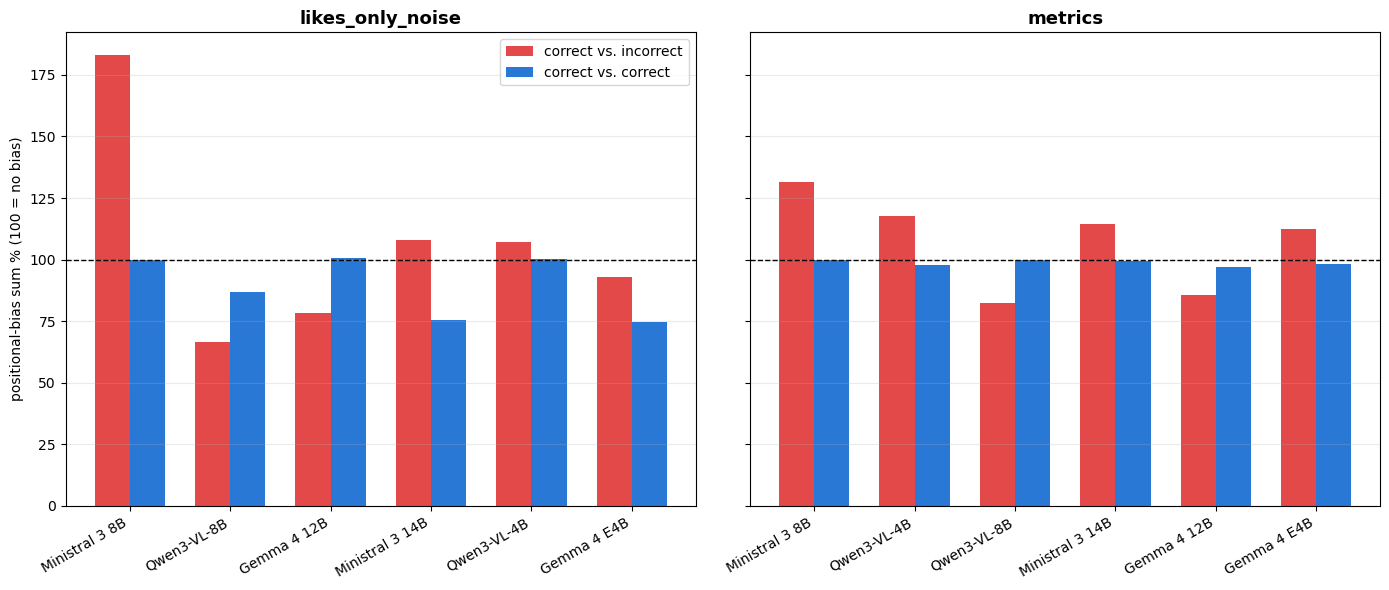

In [17]:
def plot_positional_bias():
    fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)
    width = 0.35

    for ax, condition in zip(axes, GRID_CONDITIONS):
        rows = [r for r in position_summary if r[1] == condition]
        rows.sort(key=lambda r: abs(r[2] - 100) if r[2] is not None else 0, reverse=True)
        labels = [r[0] for r in rows]
        ci_vals = [r[2] for r in rows]
        cvc_vals = [r[3] for r in rows]
        xs = list(range(len(labels)))

        ax.bar([x - width/2 for x in xs], ci_vals, width, label="correct vs. incorrect", color="#e34948")
        ax.bar([x + width/2 for x in xs], cvc_vals, width, label="correct vs. correct", color="#2a78d6")
        ax.axhline(100, color="black", lw=1, ls="--")
        ax.set_xticks(xs)
        ax.set_xticklabels(labels, rotation=30, ha="right")
        ax.set_title(condition, fontsize=13, fontweight="bold")
        ax.grid(alpha=0.25, axis="y")

    axes[0].set_ylabel("positional-bias sum % (100 = no bias)")
    axes[0].legend(fontsize=10, loc="best")
    #fig.suptitle("Positional (slot A/B) bias — correct-vs-incorrect vs. correct-vs-correct", fontsize=14, fontweight="bold")
    plt.tight_layout()
    plt.savefig("positional_bias_c_vs_c_c_vs_i.png", dpi=300, bbox_inches="tight")
    plt.show()


plot_positional_bias()

## Cross-domain comparison + Phase 1 link

Two additions pulled in from the other notebooks / the Phase 1 benchmarking outputs, computed fresh from the saved JSON/CSV files (nothing re-run):
- **Cross-domain table**: this study's effect score next to Climate's and Authority's own numbers, side by side.
- **Phase 1 link**: each model's Phase 1 fact-check accuracy (`benchmarking/`, zero engagement pressure at all) next to its Phase 2 effect score here.

In [18]:
import csv, re
from collections import defaultdict

_CROSS_SCALES = [0, 10, 100, 1000, 10000, 100000, 1000000]
_BENCH_SLUG_MAP = {"gemma4-e4b": "gemma-e4b"}  # benchmarking/ names this one model differently


def _cd_mean_effect_gap_pct(paired_json_path):
    """Engagement-effect score for a correct_scale/incorrect_scale paired grid, expressed as a
    percentage-point gap rather than a ratio: mean over all cross-scale pairs of
    (advantaged-side accuracy% - disadvantaged-side accuracy%).

    0% = engagement has no effect on which post gets liked. 100% = complete override (the
    advantaged post always wins regardless of correctness). Negative % means the model actually
    prefers the DISADVANTAGED (lower-engagement) post -- a reversed relationship, seen for
    Gemma-12B on climate (see flag below). Unlike the previous ratio-based score
    (1 - disadv_pct/adv_pct), this stays bounded to [-100, 100] and does not blow up when the
    advantaged-side accuracy is small, so it's directly comparable to the Authority column, which
    is already a percentage. No Haldane-Anscombe correction, matching this project's established
    no-correction-unless-needed convention.
    """
    if not paired_json_path.exists():
        return None
    grid = defaultdict(list)
    for r in json.loads(paired_json_path.read_text()):
        if r.get("liked_variant") not in ("correct", "incorrect"):
            continue
        grid[(r["correct_scale"], r["incorrect_scale"])].append(r["liked_variant"] == "correct")
    gaps = []
    for cs in _CROSS_SCALES:
        for ics in _CROSS_SCALES:
            if cs >= ics:
                continue
            disadv, adv = grid.get((cs, ics)), grid.get((ics, cs))
            if not disadv or not adv:
                continue
            disadv_pct = 100 * sum(disadv) / len(disadv)
            adv_pct = 100 * sum(adv) / len(adv)
            gaps.append(adv_pct - disadv_pct)
    return sum(gaps) / len(gaps) if gaps else None


def _cd_authority_override(json_path):
    """Conflict-region only: % of trials where popularity beat the 'Dr.' authority cue
    (100 - % chose Dr). Correctness is held equal on both sides in this pilot, so this
    measures engagement overriding AUTHORITY, not engagement overriding correctness --
    a related but distinct manipulation from the effect score above."""
    if not json_path.exists():
        return None
    data = json.loads(json_path.read_text())
    conflict = [r for r in data if r.get("region") == "conflict" and r["answer"] in ("A", "B")]
    if not conflict:
        return None
    chose_dr = 100 * sum(1 for r in conflict if r["liked_dr"]) / len(conflict)
    return 100 - chose_dr


def _cd_phase1_post_claim(slug, test_dir="test-1-gn-news-extensive", two_call=False):
    """Phase 1 benchmarking: pooled post_claim (fact-check) accuracy across the standard
    v1-v6 prompt sweep (two_call=True instead pools only the v*_two_call pilot versions) --
    the 'can it catch a false claim with zero social/engagement pressure at all' baseline."""
    bench_slug = _BENCH_SLUG_MAP.get(slug, slug)
    base = REPO_ROOT / "benchmarking/outputs" / bench_slug / "quantitative" / test_dir
    if not base.exists():
        return None
    pattern = re.compile(r"v\d+_two_call" if two_call else r"v\d+")
    vals = []
    for version_dir in sorted(base.iterdir()):
        if not pattern.fullmatch(version_dir.name):
            continue
        for csv_path in version_dir.glob("accuracy_scores_v*.csv"):
            with open(csv_path, newline="") as f:
                for row in csv.DictReader(f):
                    if "post_claim_correct_correct" in row:
                        vals.append(row["post_claim_correct_correct"] == "True")
    return 100 * sum(vals) / len(vals) if vals else None


def _cd_fmt_pct(score):
    """Format a percentage score, flagging negative (reversed-preference) values instead of
    letting them read as a plain small number."""
    if score is None:
        return "-"
    if score < 0:
        return f"{score:.1f}%*"
    return f"{score:.1f}%"


print(f"\n{'='*95}\nCross-domain comparison — how often a fake popularity signal overrides the legitimate cue\n{'='*95}")
print("All columns are now on the same 0-100% scale: % of the accuracy gap between the two sides")
print("of a comparison that gets closed by fake popularity, rather than by the legitimate cue.")
print("E1 main / Climate: engagement overriding CORRECTNESS (0%=resists engagement entirely,")
print("100%=fully overridden). A NEGATIVE value (marked *) means the model actually prefers the")
print("LOWER-engagement post -- a reversed relationship, not just 'no effect'.")
print("Authority (conflict region only): engagement overriding an AUTHORITY cue -- correctness is")
print("held equal on both sides there, so this is a related but distinct manipulation, not directly")
print("additive with the other two columns.\n")
print(f"{'model':17s}{'E1 main':>12s}{'E1 Climate':>14s}{'Authority override':>22s}")
for label, slug in ROSTER:
    e1_score = _cd_mean_effect_gap_pct(REPO_ROOT / "experiments/e1" / slug / "outputs/e1_results_metrics_paired.json")
    cl_score = _cd_mean_effect_gap_pct(REPO_ROOT / "experiments/e1_climate" / slug / "outputs/e1_results_metrics_paired.json")
    au_score = _cd_authority_override(REPO_ROOT / "experiments/e1_authority_grid" / slug / "outputs/e1_results_authority_grid_metrics.json")
    print(f"{label:17s}{_cd_fmt_pct(e1_score):>12s}{_cd_fmt_pct(cl_score):>14s}{_cd_fmt_pct(au_score):>22s}")
print("\n* negative = model prefers the disadvantaged (lower-engagement) post on average across the grid.")

print(f"\n{'='*80}\nPhase 1 fact-check accuracy (zero social pressure) vs. Phase 2 conformity here\n{'='*80}")
print(f"{'model':17s}{'Phase 1 post_claim %':>22s}{'Phase 2 Climate %':>20s}")
for label, slug in ROSTER:
    p1 = _cd_phase1_post_claim(slug)
    p2 = _cd_mean_effect_gap_pct(REPO_ROOT / "experiments/e1_climate" / slug / "outputs/e1_results_metrics_paired.json")
    p1_str = f"{p1:.1f}%" if p1 is not None else "-"
    print(f"{label:17s}{p1_str:>22s}{_cd_fmt_pct(p2):>20s}")
    if slug == "qwen3-vl-8b":
        p1_two_call = _cd_phase1_post_claim(slug, two_call=True)
        if p1_two_call is not None:
            print(f"  ↳ same model, two-call pilot (v7-v9, describe-then-verify): {p1_two_call:.1f}% post_claim")



Cross-domain comparison — how often a fake popularity signal overrides the legitimate cue
All columns are now on the same 0-100% scale: % of the accuracy gap between the two sides
of a comparison that gets closed by fake popularity, rather than by the legitimate cue.
E1 main / Climate: engagement overriding CORRECTNESS (0%=resists engagement entirely,
100%=fully overridden). A NEGATIVE value (marked *) means the model actually prefers the
LOWER-engagement post -- a reversed relationship, not just 'no effect'.
Authority (conflict region only): engagement overriding an AUTHORITY cue -- correctness is
held equal on both sides there, so this is a related but distinct manipulation, not directly
additive with the other two columns.

model                 E1 main    E1 Climate    Authority override
Gemma 4 12B              5.6%       -61.5%*                 28.4%
Qwen3-VL-8B             93.5%         98.9%                 98.7%
Ministral 3 14B         99.6%         98.5%                 99.2

# Correct vs Incorrect

✅ Saved to: /home/jovyan/conformity-llms-facebook-posts/experiments/e1/e1_grid_overview_likes_only_noise.png


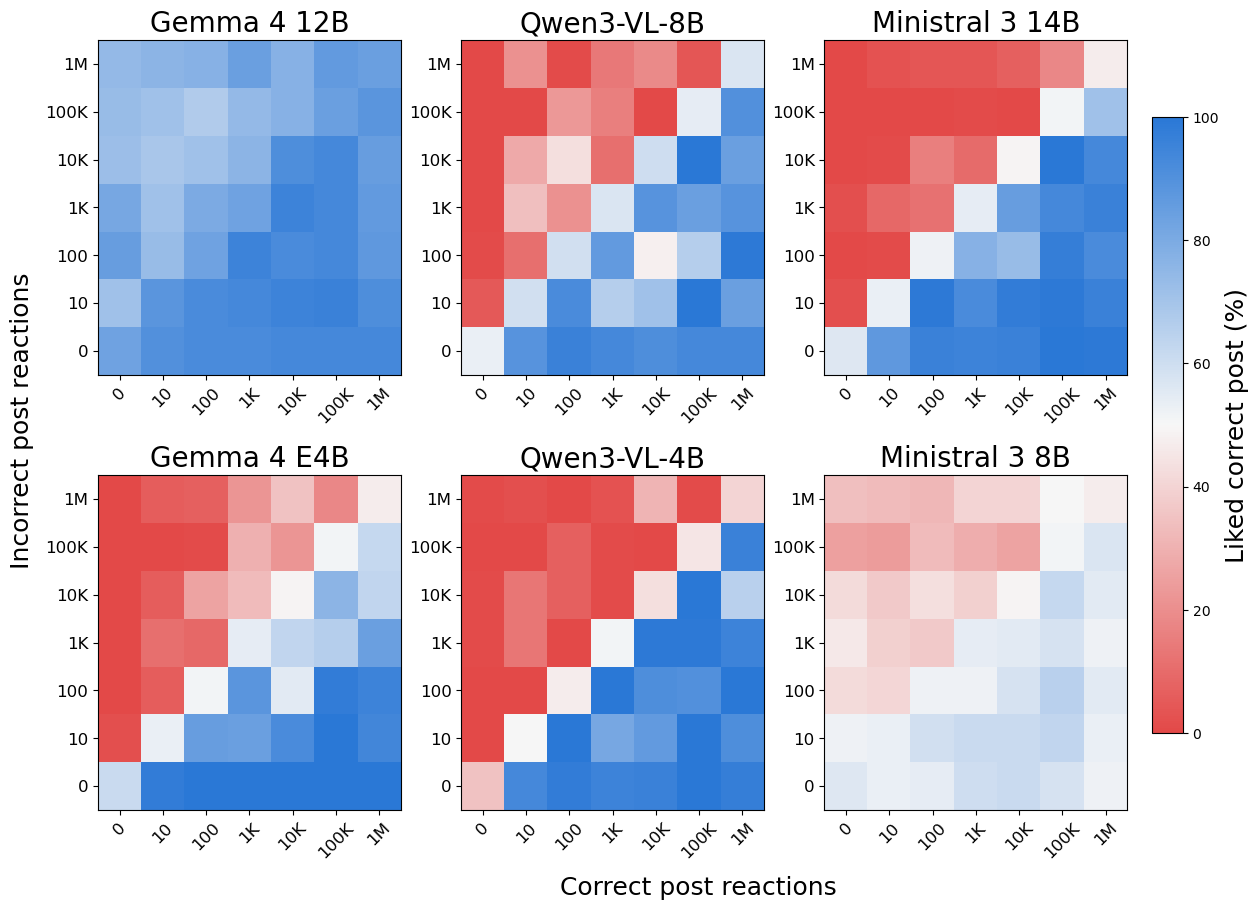

✅ Saved to: /home/jovyan/conformity-llms-facebook-posts/experiments/e1/e1_grid_overview_metrics.png


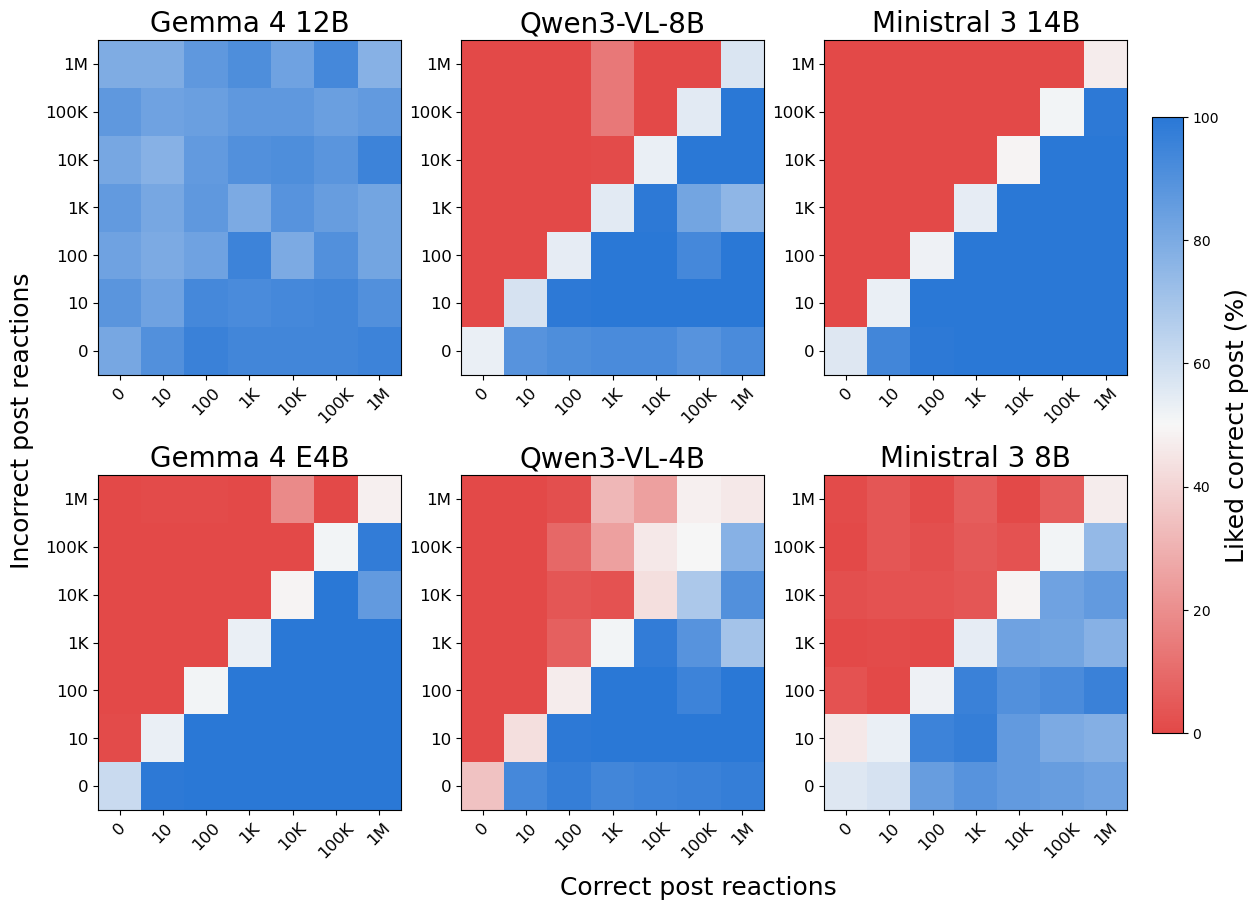

In [19]:
LABELS = ["0", "10", "100", "1K", "10K", "100K", "1M"]

def e1_grid_matrix(slug, condition):
    """Same cell layout as plot_ab_grid: rows = incorrect_scale, cols = correct_scale."""
    grid = load_paired_grid(slug, condition)
    n = len(SCALES)
    pct = [[None] * n for _ in range(n)]
    for i, ics in enumerate(SCALES):
        for j, cs in enumerate(SCALES):
            cell = grid.get((cs, ics))
            if cell:
                pct[i][j] = 100 * sum(cell) / len(cell)
    return pct


def plot_e1_grid_overview(condition="metrics", models=None, save_path=None):
    """All six models' correct-vs-incorrect grids as one 2x3 figure -- same colors and axis
    convention as plot_ab_grid (no changes to that convention, just combined into one figure)."""
    import numpy as np
    import matplotlib.pyplot as plt
    import matplotlib.colors as mcolors

    models = models or ROSTER
    n = len(SCALES)
    cmap = mcolors.LinearSegmentedColormap.from_list("rb", ["#e34948", "#f7f7f7", "#2a78d6"])
    fig, axes = plt.subplots(2, 3, figsize=(16, 10), gridspec_kw={"hspace": 0.3})
    flat = axes.flatten()
    im = None

    for ax, (label, slug) in zip(flat, models):
        pct = e1_grid_matrix(slug, condition)
        grid = np.array([[np.nan if v is None else v for v in row] for row in pct])
        im = ax.imshow(grid, cmap=cmap, vmin=0, vmax=100, aspect="auto")
        
        # for i in range(n):
        #     for j in range(n):
        #         if not np.isnan(grid[i][j]):
        #             ax.text(j, i, f"{grid[i][j]:.0f}%", ha="center", va="center",
        #                     fontsize=9, fontweight="bold", color="black")
                    
        ax.set_title(label, fontsize=20)
        ax.set_xticks(range(n)); ax.set_yticks(range(n))
        ax.set_xticklabels(LABELS, fontsize=12, rotation=45)
        ax.set_yticklabels(LABELS, fontsize=12)
        ax.invert_yaxis()

    fig.supxlabel("Correct post reactions", fontsize=18, y=0.02)
    fig.supylabel("Incorrect post reactions", fontsize=18, x=0.07)
    #fig.suptitle(f"% chose correct — E1 main, {condition}", fontsize=16, fontweight="bold", y=1.02)
    if im is not None:
        cbar = fig.colorbar(im, ax=flat.tolist(), shrink=0.8, pad=0.02)
        cbar.set_label("Liked correct post (%)", fontsize=18)

    if save_path:
        Path(save_path).parent.mkdir(parents=True, exist_ok=True)
        plt.savefig(save_path, dpi=300, bbox_inches="tight")
        print(f"✅ Saved to: {save_path}")
    plt.show()


plot_e1_grid_overview("likes_only_noise",
                       save_path=REPO_ROOT / "experiments/e1" / "e1_grid_overview_likes_only_noise.png")
plot_e1_grid_overview("metrics",
                       save_path=REPO_ROOT / "experiments/e1" / "e1_grid_overview_metrics.png")

✅ Saved to: /home/jovyan/conformity-llms-facebook-posts/experiments/e1/e1_cvc_grid_overview_likes_only_noise.png


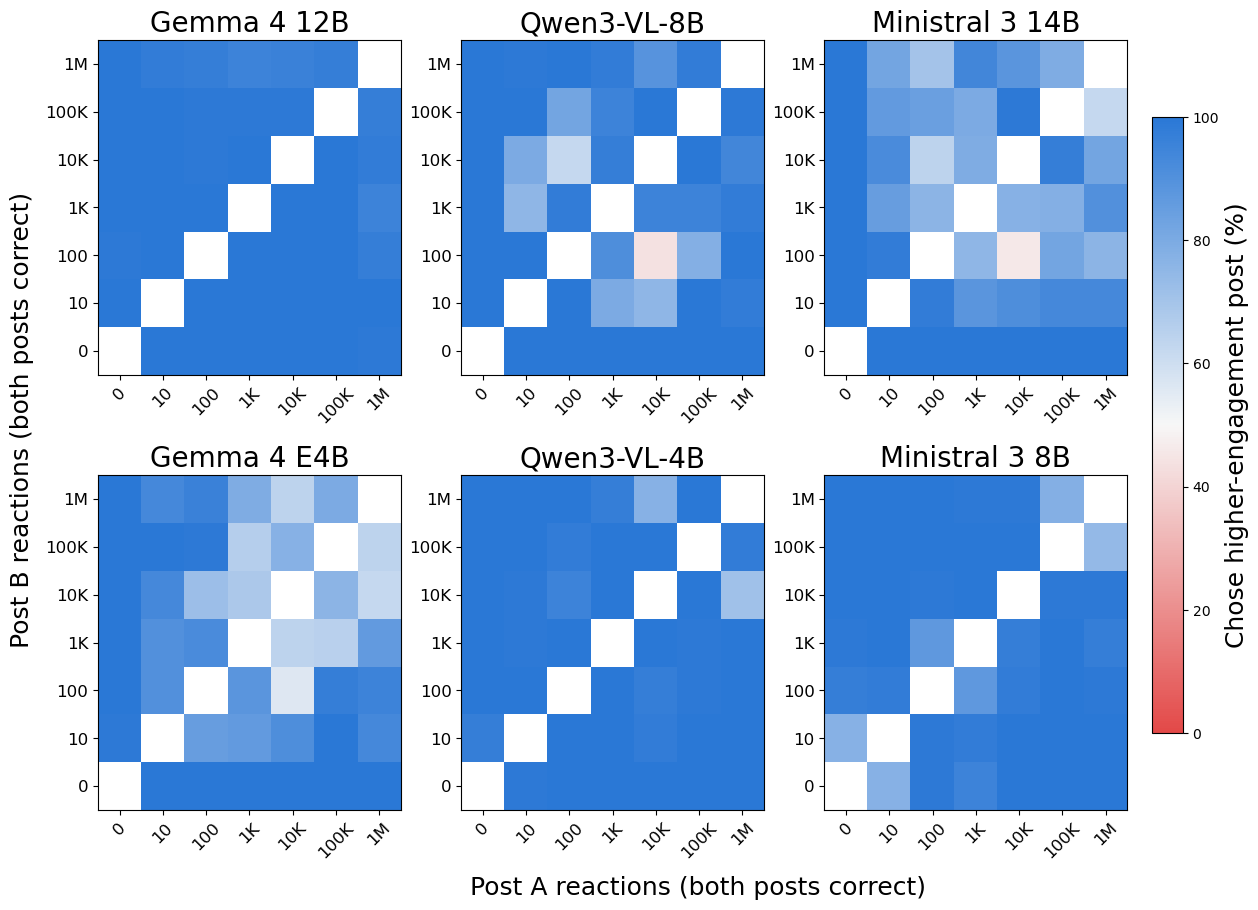

✅ Saved to: /home/jovyan/conformity-llms-facebook-posts/experiments/e1/e1_cvc_grid_overview_metrics.png


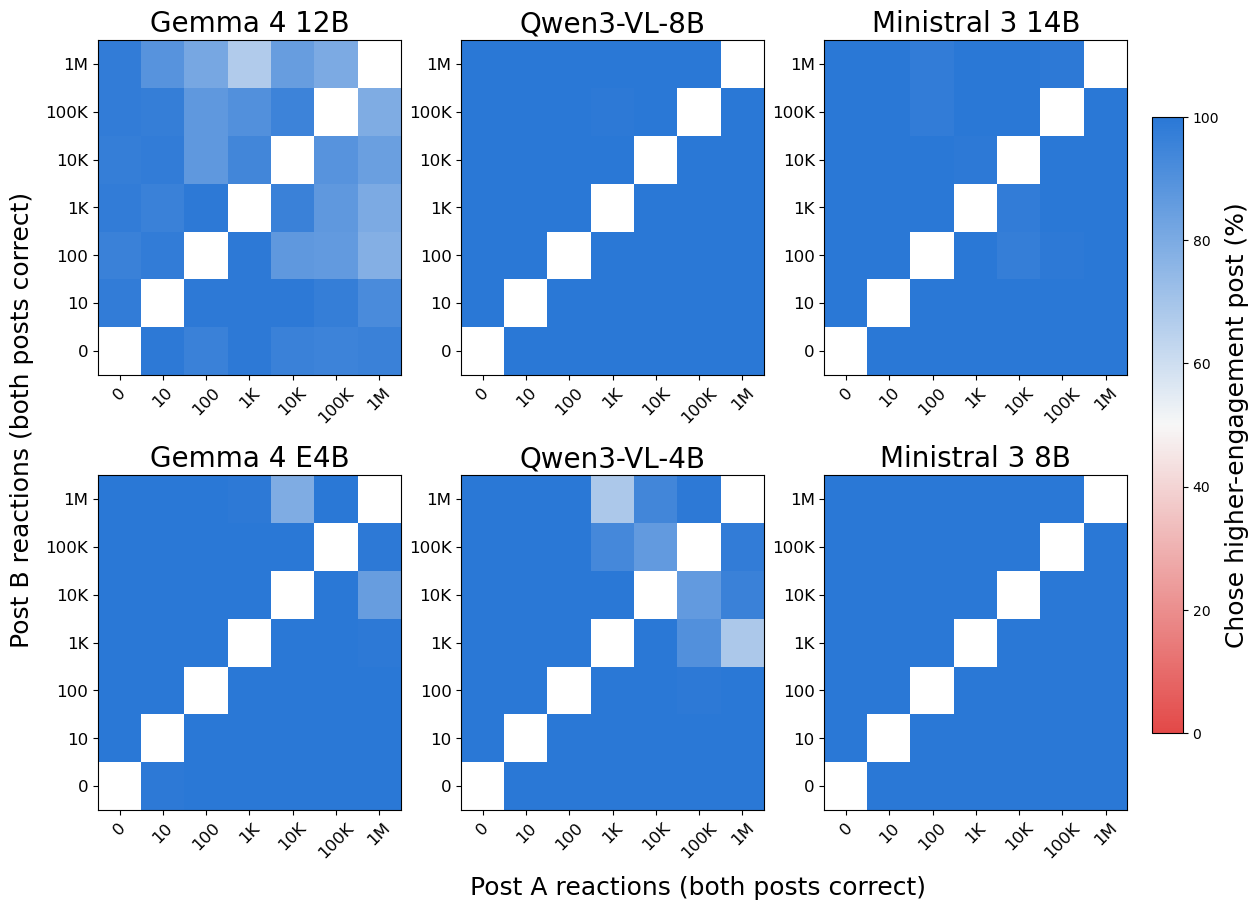

In [20]:
def e1_cvc_grid_matrix(slug, condition):
    """Correct-vs-correct control: % chose the higher-engagement post"""
    f = REPO_ROOT / "experiments/e1" / slug / "outputs" / f"e1_results_{condition}_correct_vs_correct_paired.json"
    if not f.exists():
        print(f"  ⚠ missing: {f.relative_to(REPO_ROOT)}")
        return [[None] * len(SCALES) for _ in SCALES]
    grid = defaultdict(list)
    for r in json.loads(f.read_text()):
        if r["scale_a"] == r["scale_b"]:
            continue
        grid[(r["scale_a"], r["scale_b"])].append(bool(r["liked_higher_engagement"]))
    n = len(SCALES)
    pct = [[None] * n for _ in range(n)]
    for i, scale_b in enumerate(SCALES):
        for j, scale_a in enumerate(SCALES):
            vals = grid.get((scale_a, scale_b))
            if vals:
                pct[i][j] = 100 * sum(vals) / len(vals)
    return pct


def plot_e1_cvc_grid_overview(condition="metrics", models=None, save_path=None):
    """All six models' correct-vs-correct control grids (chose higher-engagement %) as one
    2x3 figure -- same metric, colors, and axis convention as plot_cc_grid
    (e1_utils/e1_analysis_optimized.py), combined the way plot_e1_grid_overview (cell 34)
    combines the main correct-vs-incorrect grids."""
    import numpy as np
    import matplotlib.colors as mcolors

    models = models or ROSTER
    n = len(SCALES)
    cmap = mcolors.LinearSegmentedColormap.from_list("rb", ["#e34948", "#f7f7f7", "#2a78d6"])
    fig, axes = plt.subplots(2, 3, figsize=(16, 10), gridspec_kw={"hspace": 0.3})
    flat = axes.flatten()
    im = None

    for ax, (label, slug) in zip(flat, models):
        pct = e1_cvc_grid_matrix(slug, condition)
        grid = np.array([[np.nan if v is None else v for v in row] for row in pct])
        im = ax.imshow(grid, cmap=cmap, vmin=0, vmax=100, aspect="auto")
        # for i in range(n):
        #     for j in range(n):
        #         if not np.isnan(grid[i][j]):
        #             ax.text(j, i, f"{grid[i][j]:.0f}%", ha="center", va="center",
        #                     fontsize=9, fontweight="bold", color="black")
        ax.set_title(label, fontsize=20)
        ax.set_xticks(range(n)); ax.set_yticks(range(n))
        ax.set_xticklabels(LABELS, fontsize=12, rotation=45)
        ax.set_yticklabels(LABELS, fontsize=12)
        ax.invert_yaxis()

    fig.supxlabel("Post A reactions (both posts correct)", fontsize=18, y=0.02)
    fig.supylabel("Post B reactions (both posts correct)", fontsize=18, x=0.07)
    #fig.suptitle(f"Correct vs. correct control — chose higher-engagement post %, {condition}", fontsize=16, fontweight="bold", y=1.02)
    if im is not None:
        cbar = fig.colorbar(im, ax=flat.tolist(), shrink=0.8, pad=0.02)
        cbar.set_label("Chose higher-engagement post (%)", fontsize=18)

    if save_path:
        Path(save_path).parent.mkdir(parents=True, exist_ok=True)
        plt.savefig(save_path, dpi=300, bbox_inches="tight")
        print(f"✅ Saved to: {save_path}")
    plt.show()


plot_e1_cvc_grid_overview("likes_only_noise",
                           save_path=REPO_ROOT / "experiments/e1" / "e1_cvc_grid_overview_likes_only_noise.png")
plot_e1_cvc_grid_overview("metrics",
                           save_path=REPO_ROOT / "experiments/e1" / "e1_cvc_grid_overview_metrics.png")

# Logistic regression: does engagement move the choice, and how does it weigh against correctness?

Two small logistic regressions, one per claim, run once per model rather than pooled togethe
.
Claim 1 uses the correct vs correct grid (does engagement alone move the choice, with no tr th
at ste). Claim 2 uses the main correct vs incorrect grid (does engagement still win once one
post is actually wrong, and how does that compare to simply being ct). run on n on
`metrics` and on `like_noises_only`, so the two conditions can be compared directly.

# Claim 1

In [21]:
import warnings
import numpy as np
import pandas as pd
import statsmodels.api as sm

RANK = {0: 0, 10: 1, 100: 2, 1000: 3, 10000: 4, 100000: 5, 1000000: 6}

def load_json(slug, fname):
    f = REPO_ROOT / "experiments/e1" / slug / "outputs" / fname
    return json.loads(f.read_text())

def sigmoid(x):
    return 1.0 / (1.0 + np.exp(-x))

def fit_logit(df, xcols, cluster_col):
    """
    Fits chose_A ~ xcols with cluster robust standard errors, clustering by image
    (the same 100 base images repeat across many trials, so answers about the same
    image are treated as related rather than fully independent).

    Falls back to a gentle ridge penalized fit when the plain fit is unstable, which
    happens when a model's answers are so one sided for a predictor that the estimate
    would otherwise blow up toward an impossibly large number (statisticians call this
    complete separation).
    """
    X = sm.add_constant(df[xcols].astype(float))
    y = df["chose_A"].astype(float)
    groups = df[cluster_col].values
    unstable = False
    res = None
    try:
        res = sm.Logit(y, X).fit(disp=0, method="newton", maxiter=200,
                                  cov_type="cluster", cov_kwds={"groups": groups})
        if not res.mle_retvals.get("converged", True) or (np.abs(res.params) > 9).any():
            unstable = True
    except Exception as e:
        warnings.warn(f"plain fit failed ({e})")
        unstable = True
    ridge_params = None
    if unstable:
        ridge_params = sm.Logit(y, X).fit_regularized(
            disp=0, alpha=1.0, L1_wt=0.0, maxiter=500).params
    return res, unstable, ridge_params

In [22]:
# claim 1
def run_claim1(cvc_fname):
    """Correct vs correct: does engagement alone move the choice, with no truth at stake?"""
    rows = []
    for label, slug in ROSTER:
        df = pd.DataFrame(load_json(slug, cvc_fname))
        # post_a_scale / post_b_scale are the true randomized slot values.
        # scale_a / scale_b are just naming labels from the image pairing and do NOT
        # reliably match which post actually sat in slot A vs slot B, so don't use
        # them for anything that depends on slot identity like this does.
        df["edge_A"] = df["post_a_scale"].map(RANK) - df["post_b_scale"].map(RANK)
        df = df[df["edge_A"] != 0].copy()  # ties carry no information for this question
        df["chose_A"] = (df["answer"] == "A").astype(int)
        df["image_id"] = df["num"]

        res, unstable, ridge = fit_logit(df, ["edge_A"], "image_id")
        params = ridge if unstable else res.params
        slope, intercept = params["edge_A"], params["const"]
        rows.append({
            "model": label, "n": len(df), "unstable": unstable,
            "odds_per_rung": np.exp(slope),
            "p_bigger_wins_1_rung_apart": sigmoid(intercept + slope * 1),
            "p_bigger_wins_6_rungs_apart": sigmoid(intercept + slope * 6),
        })
    return pd.DataFrame(rows)


claim1_metrics = run_claim1("e1_results_metrics_correct_vs_correct_paired.json")
claim1_likes = run_claim1("e1_results_likes_only_noise_correct_vs_correct_paired.json")

def format_claim1_table(df, as_percent=True):
    """Friendlier version of a claim 1 results table.
    as_percent=True  -> chances shown as 0-100% strings (easiest to read).
    as_percent=False -> chances left as plain 0-1 numbers, just rounded (easiest to
    reuse later in more math or a plot).
    """
    out = df.sort_values("odds_per_rung").copy()
    out["model"] = out.apply(
        lambda r: f"{r['model']} (adjusted)" if r["unstable"] else r["model"], axis=1
    )
    prob_cols = ["p_bigger_wins_1_rung_apart", "p_bigger_wins_6_rungs_apart"]
    if as_percent:
        out["odds_per_rung"] = out["odds_per_rung"].map(lambda x: f"{x:,.1f}x")
        for col in prob_cols:
            out[col] = (out[col] * 100).map(lambda x: f"{x:.1f}%")
    else:
        out["odds_per_rung"] = out["odds_per_rung"].round(1)
        for col in prob_cols:
            out[col] = out[col].round(3)

    out = out[["model", "odds_per_rung"] + prob_cols]
    out.columns = ["Model", "Odds per rung", "Chance of choosing the post with higher engagement, 10 vs 100", "Chance of choosing the post with higher engagement, 0 vs 1,000,000"]
    return out

/opt/conda/lib/python3.11/site-packages/statsmodels/discrete/discrete_model.py:227: PerfectSeparationWarning: Perfect separation or prediction detected, parameter may not be identified
  warnings.warn(msg, category=PerfectSeparationWarning)
/opt/conda/lib/python3.11/site-packages/statsmodels/discrete/discrete_model.py:227: PerfectSeparationWarning: Perfect separation or prediction detected, parameter may not be identified
  warnings.warn(msg, category=PerfectSeparationWarning)
/opt/conda/lib/python3.11/site-packages/statsmodels/discrete/discrete_model.py:227: PerfectSeparationWarning: Perfect separation or prediction detected, parameter may not be identified
  warnings.warn(msg, category=PerfectSeparationWarning)
/opt/conda/lib/python3.11/site-packages/statsmodels/discrete/discrete_model.py:227: PerfectSeparationWarning: Perfect separation or prediction detected, parameter may not be identified
  warnings.warn(msg, category=PerfectSeparationWarning)
/opt/conda/lib/python3.11/site-packa

In [23]:
#display(format_claim1_table(claim1_metrics, as_percent=True))
print("Likes Only")
display(format_claim1_table(claim1_likes, as_percent=False))
print()
print("Mixed Metrics")
display(format_claim1_table(claim1_metrics, as_percent=False))

Likes Only


,Model,Odds per rung,"Chance of choosing the post with higher engagement, 10 vs 100","Chance of choosing the post with higher engagement, 0 vs 1,000,000"
2,Ministral 3 14B,2.5,0.431,0.987
3,Gemma 4 E4B,3.2,0.407,0.995
1,Qwen3-VL-8B,3.4,0.583,0.998
5,Ministral 3 8B,7.5,0.879,1.000
4,Qwen3-VL-4B,8.6,0.902,1.000
0,Gemma 4 12B,13.3,0.941,1.000



Mixed Metrics


,Model,Odds per rung,"Chance of choosing the post with higher engagement, 10 vs 100","Chance of choosing the post with higher engagement, 0 vs 1,000,000"
0,Gemma 4 12B,2.4,0.678,0.994
4,Qwen3-VL-4B,5.4,0.807,1.000
3,Gemma 4 E4B,18.0,0.910,1.000
2,Ministral 3 14B,50.4,0.968,1.000
1,Qwen3-VL-8B,693.6,0.998,1.000
5,Ministral 3 8B (adjusted),1200.5,0.999,1.000


In [24]:
THESIS_ORDER = ["Gemma 4 12B", "Gemma 4 E4B", "Qwen3-VL-8B",
                "Qwen3-VL-4B", "Ministral 3 14B", "Ministral 3 8B"]

signal_comparison_cvc = pd.DataFrame({
    "model": claim1_metrics["model"],
    "odds_per_rung_metrics": claim1_metrics["odds_per_rung"],
    "odds_per_rung_likes_only": claim1_likes["odds_per_rung"],
})

def reorder(df, order=THESIS_ORDER):
    return df.set_index("model").reindex(order).reset_index()
    
signal_comparison_cvc = reorder(signal_comparison_cvc) 

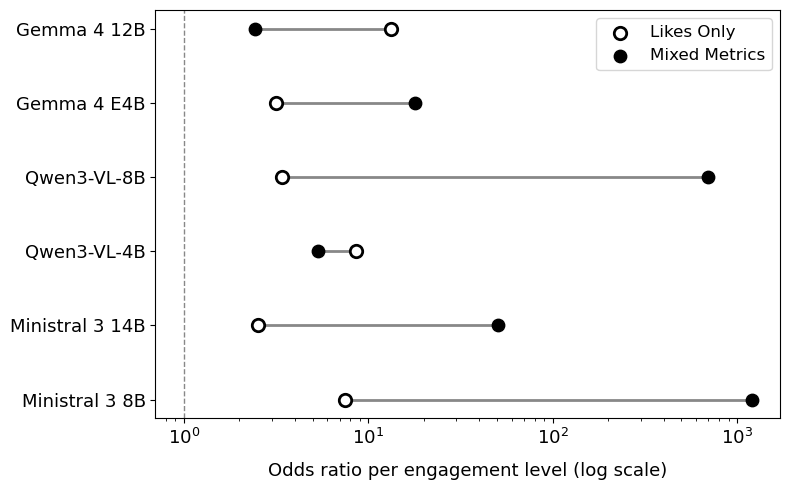

In [25]:
fig, ax = plt.subplots(figsize=(8, 5))
y = np.arange(len(signal_comparison_cvc))
for i, row in signal_comparison_cvc.iterrows():
    ax.plot([row["odds_per_rung_likes_only"], row["odds_per_rung_metrics"]], [i, i],
            color="#888888", lw=2, zorder=1)
ax.scatter(signal_comparison_cvc["odds_per_rung_likes_only"], y,
           facecolors="white", edgecolors="black", linewidths=2,
           label="Likes Only", zorder=2, s=80)
ax.scatter(signal_comparison_cvc["odds_per_rung_metrics"], y,
           facecolors="black", edgecolors="black",
           label="Mixed Metrics", zorder=2, s=80)
ax.set_xscale("log")
ax.tick_params(axis='x', labelsize=13)
ax.set_yticks(y)
ax.set_yticklabels(signal_comparison_cvc["model"], fontsize=13)
ax.axvline(1, color="#888888", ls="--", lw=1)
ax.set_xlabel("Odds ratio per engagement level (log scale)", fontsize=13,  labelpad=10)
ax.legend(fontsize=12)
plt.tight_layout()
ax.invert_yaxis()
plt.savefig("engagement_likes_v_metrics_cvc.png", dpi=300, bbox_inches="tight")
plt.show()

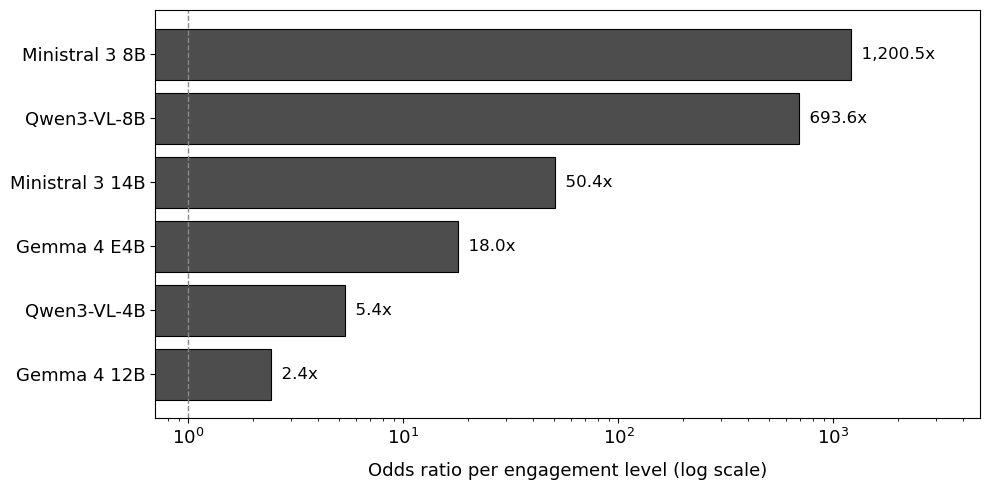

In [26]:
# mixed metrics
fig, ax = plt.subplots(figsize=(10, 5))
c1_sorted = claim1_metrics.sort_values("odds_per_rung")
ax.barh(c1_sorted["model"], c1_sorted["odds_per_rung"], color="#4d4d4d", edgecolor="black", linewidth=0.8)
ax.set_xscale("log")
ax.tick_params(axis='both', labelsize=13)  # <-- now applies to x AND y
ax.axvline(1, color="#888888", ls="--", lw=1)
ax.set_xlim(right=c1_sorted["odds_per_rung"].max() * 4)  # <-- more headroom on the right
ax.set_xlabel("Odds ratio per engagement level (log scale)", fontsize=13, labelpad=10)
for y, v in enumerate(c1_sorted["odds_per_rung"]):
    ax.text(v, y, f"  {v:,.1f}x", va="center", fontsize=12)
plt.tight_layout()
plt.savefig("engagement_pull_c_v_c.png", dpi=300, bbox_inches="tight")
plt.show()



# Claim 2

In [27]:
# cliam 2, both conditions

ROSTER = [
    ("Gemma 4 12B", "gemma4-12b"),
    ("Gemma 4 E4B", "gemma4-e4b"),
    ("Qwen3-VL-8B", "qwen3-vl-8b"),
    ("Qwen3-VL-4B", "qwen3-vl-4b"),
    ("Ministral 3 14B", "ministral-3-14b"),
    ("Ministral 3 8B", "ministral-3-8b"),
]

def run_claim2(grid_fname, fallback_fname=None):
    """Correct vs incorrect: does relative engagement move the choice, weighed against
    correctness itself?"""
    rows = []
    for label, slug in ROSTER:
        fname_used = grid_fname
        try:
            grid = load_json(slug, grid_fname)
        except FileNotFoundError:
            if fallback_fname is None:
                raise
            grid = load_json(slug, fallback_fname)
            fname_used = fallback_fname
        df = pd.DataFrame(grid)
        df = df[df["liked_variant"].isin(["correct", "incorrect"])].copy()  # drop refusals
        df["scale_A"] = np.where(df["post_a_variant"] == "correct", df["correct_scale"], df["incorrect_scale"])
        df["scale_B"] = np.where(df["post_b_variant"] == "correct", df["correct_scale"], df["incorrect_scale"])
        df["edge_A"] = df["scale_A"].map(RANK) - df["scale_B"].map(RANK)
        df["correct_in_A"] = (df["post_a_variant"] == "correct").astype(int)
        df["chose_A"] = (df["answer"] == "A").astype(int)
        df["image_id"] = df["num"]

        res, unstable, ridge = fit_logit(df, ["edge_A", "correct_in_A"], "image_id")
        params = ridge if unstable else res.params
        c, e, k = params["const"], params["edge_A"], params["correct_in_A"]

        def p_correct_pooled(edge_in_favor_of_correct):
            # average both slot arrangements, so this isn't just describing
            # what happens when the correct post happens to sit in slot A
            p_a = sigmoid(c + e * edge_in_favor_of_correct + k)
            p_b = 1 - sigmoid(c + e * (-edge_in_favor_of_correct))
            return 0.5 * p_a + 0.5 * p_b

        rows.append({
            "model": label, "n": len(df), "unstable": unstable, "file_used": fname_used,
            "engagement_odds_per_rung": np.exp(e),
            "correctness_odds": np.exp(k),
            "predicted_diagonal_pct": 100 * p_correct_pooled(0),
        })
    return pd.DataFrame(rows)

claim2_metrics = run_claim2("e1_results_metrics_paired.json")
claim2_likes_only = run_claim2("e1_results_likes_only_noise_paired.json")

signal_comparison = pd.DataFrame({
    "model": claim2_metrics["model"],
    "odds_per_rung_metrics": claim2_metrics["engagement_odds_per_rung"],
    "odds_per_rung_likes_only": claim2_likes_only["engagement_odds_per_rung"],
})

def format_claim2_table(df, default_fname, as_percent=True):
    """Friendlier version of a claim 2 results table.
    as_percent=True  -> predicted diagonal shown as a 0-100% string, odds shown as
    'x' multipliers (easiest to read).
    as_percent=False -> predicted diagonal left as a plain 0-1 number, odds left as
    plain rounded multipliers (easiest to reuse later in more math or a plot).

    default_fname is whichever file name you passed into run_claim2 as its main
    grid_fname, so any row that actually used the fallback file instead gets flagged.
    """
    out = df.sort_values("engagement_odds_per_rung").copy()

    def label_model(r):
        name = r["model"]
        if r["unstable"]:
            name += " (adjusted)"
        if r["file_used"] != default_fname:
            name += " (fallback file)"
        return name

    out["model"] = out.apply(label_model, axis=1)

    if as_percent:
        out["engagement_odds_per_rung"] = out["engagement_odds_per_rung"].map(lambda x: f"{x:,.1f}x")
        out["correctness_odds"] = out["correctness_odds"].map(lambda x: f"{x:,.1f}x")
        out["predicted_diagonal_pct"] = out["predicted_diagonal_pct"].map(lambda x: f"{x:.1f}%")
    else:
        out["engagement_odds_per_rung"] = out["engagement_odds_per_rung"].round(1)
        out["correctness_odds"] = out["correctness_odds"].round(1)
        out["predicted_diagonal_pct"] = (out["predicted_diagonal_pct"] / 100).round(3)

    out = out[["model", "engagement_odds_per_rung", "correctness_odds", "predicted_diagonal_pct"]]
    out.columns = ["Model", "Engagement odds per rung", "Correctness odds", "Predicted diagonal accuracy"]
    return out


print("Likes-only, %")
print(format_claim2_table(claim2_likes_only, "e1_results_likes_only_noise_paired.json", as_percent=True))
print("Metrics, %")
print(format_claim2_table(claim2_metrics, "e1_results_metrics_paired.json", as_percent=True))
''''

print("Likes-only, 0.1")
display(format_claim2_table(claim2_likes_only, "e1_results_likes_only_noise_paired.json", as_percent=False))
print("Metrics, 0-1")
display(format_claim2_table(claim2_metrics, "e1_results_metrics_paired.json", as_percent=False))
'''

Likes-only, %
             Model Engagement odds per rung Correctness odds  \
0      Gemma 4 12B                     1.2x            66.6x   
5   Ministral 3 8B                     1.7x             0.3x   
1      Gemma 4 E4B                     2.4x             0.9x   
2      Qwen3-VL-8B                     2.5x             1.2x   
3      Qwen3-VL-4B                     3.5x             0.7x   
4  Ministral 3 14B                     3.8x             0.7x   

  Predicted diagonal accuracy  
0                       85.4%  
5                       47.7%  
1                       48.5%  
2                       51.3%  
3                       45.3%  
4                       46.2%  
Metrics, %
                        Model Engagement odds per rung Correctness odds  \
0                 Gemma 4 12B                     1.1x            69.3x   
5              Ministral 3 8B                     3.2x             0.3x   
3                 Qwen3-VL-4B                     3.4x             1.0x   
2 

'\'\n\nprint("Likes-only, 0.1")\ndisplay(format_claim2_table(claim2_likes_only, "e1_results_likes_only_noise_paired.json", as_percent=False))\nprint("Metrics, 0-1")\ndisplay(format_claim2_table(claim2_metrics, "e1_results_metrics_paired.json", as_percent=False))\n'

### Column interpretation
- **Engagement odds per rung** is how much more likely the model is to pick whichever post has one extra rung of engagement, with the correctness of that post held fixed. This is engagement's pull on its own, stripped of any credit or blame for correctness.

- **Correctness odds** is how much more likely the model is to pick whichever post is actually correct, with the engagement gap between the two posts held fixed. This is correctness's pull on its own, stripped of any credit from having more engagement. This is exactly the number behind the white bars in the bar chart we discussed earlier.

- **Predicted diagonal accuracy** is a separate calculation, not a third independent regression coefficient. It uses the fitted equation to predict how often the model would choose the correct post specifically when engagement is perfectly tied between the two posts, but it does something the raw diagonal numbers reported elsewhere in this thesis don't do, it averages the prediction across both possible slot arrangements, correct post in A and correct post in B, and cancels out. Since a screen slot habit shows up as one slot doing better than the other, averaging both arrangements together removes that habit from the number mathematically, rather than needing a genuinely balanced sample of trials to cancel it out by luck. That makes this number a position corrected estimate of tied engagement accuracy, different from, and more trustworthy than, the raw diagonal percentages used earlier in this chapter, which do carry the slot bias.

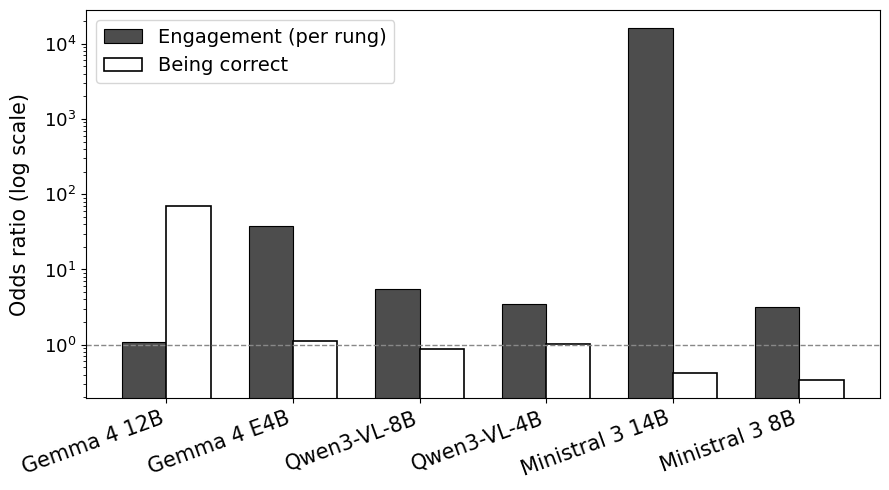

In [28]:
claim2_metrics = reorder(claim2_metrics)    

fig, ax = plt.subplots(figsize=(9, 5))
x = np.arange(len(claim2_metrics))
width = 0.35
ax.bar(x - width/2, claim2_metrics["engagement_odds_per_rung"], width,
       label="Engagement (per rung)", color="#4d4d4d", edgecolor="black", linewidth=0.8)
ax.bar(x + width/2, claim2_metrics["correctness_odds"], width,
       label="Being correct",  facecolor="white", edgecolor="black",
       linewidth=1.2)
ax.set_yscale("log")
ax.tick_params(axis='y', labelsize=13)
ax.axhline(1, color="#888888", ls="--", lw=1)
ax.set_xticks(x)
ax.set_xticklabels(claim2_metrics["model"], rotation=20, ha="right", fontsize=15)
ax.set_ylabel("Odds ratio (log scale)", fontsize=15, labelpad=10)
# ax.set_title("Claim 2: what pulls harder, engagement or correctness? (metrics)")
ax.legend(fontsize=14)
plt.tight_layout()
plt.savefig("engagement_pull_comparison_c_v_i.png", dpi=300, bbox_inches="tight")
plt.show()



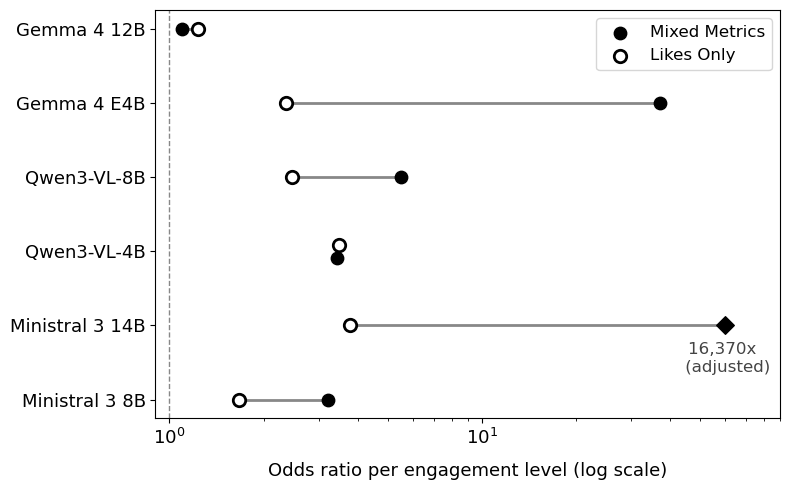

In [29]:
UNSTABLE_CAP = 60          # anything past this is clipped and flagged rather than plotted at face value
JITTER_RATIO = 1.08        # pairs closer than this ratio get nudged apart so both dots stay visible

fig, ax = plt.subplots(figsize=(8, 5))
y = np.arange(len(signal_comparison))

for i, row in signal_comparison.iterrows():
    x_likes = row["odds_per_rung_likes_only"]
    x_metrics_real = row["odds_per_rung_metrics"]
    is_unstable = x_metrics_real > UNSTABLE_CAP
    x_metrics = min(x_metrics_real, UNSTABLE_CAP)

    # if the two dots would sit closer than JITTER_RATIO in log space, nudge them apart vertically
    close = max(x_likes, x_metrics) / min(x_likes, x_metrics) < JITTER_RATIO
    y_likes = i - 0.09 if close else i
    y_metrics = i + 0.09 if close else i

    ax.plot([x_likes, x_metrics], [y_likes, y_metrics], color="#888888", lw=2, zorder=1)

    metrics_marker = "D" if is_unstable else "o"   # diamond flags the adjusted, capped point
    ax.scatter(x_metrics, y_metrics, facecolors="black", edgecolors="black",
               marker=metrics_marker, zorder=2, s=80,
               label="Mixed Metrics" if i == 0 else None)
    ax.scatter(x_likes, y_likes, facecolors="white", edgecolors="black", linewidths=2,
               zorder=3, s=80,
               label="Likes Only" if i == 0 else None)

    if is_unstable:
        ax.annotate(f"{x_metrics_real:,.0f}x \n (adjusted)",
                    xy=(x_metrics, y_metrics), xytext=(0, -12),
                    textcoords="offset points", fontsize=12,
                    ha="center", va="top", color="#444444")

ax.set_xscale("log")
ax.set_xlim(ax.get_xlim()[0], UNSTABLE_CAP * 1.5)
ax.tick_params(axis='x', labelsize=13)
ax.set_yticks(y)
ax.set_yticklabels(signal_comparison["model"], fontsize=13)
ax.axvline(1, color="#888888", ls="--", lw=1)
ax.set_xlabel("Odds ratio per engagement level (log scale)", fontsize=13, labelpad=10)
ax.legend(fontsize=12)
plt.tight_layout()
ax.invert_yaxis()
plt.savefig("engagement_likes_v_metrics_c_v_i.png", dpi=300, bbox_inches="tight")
plt.show()

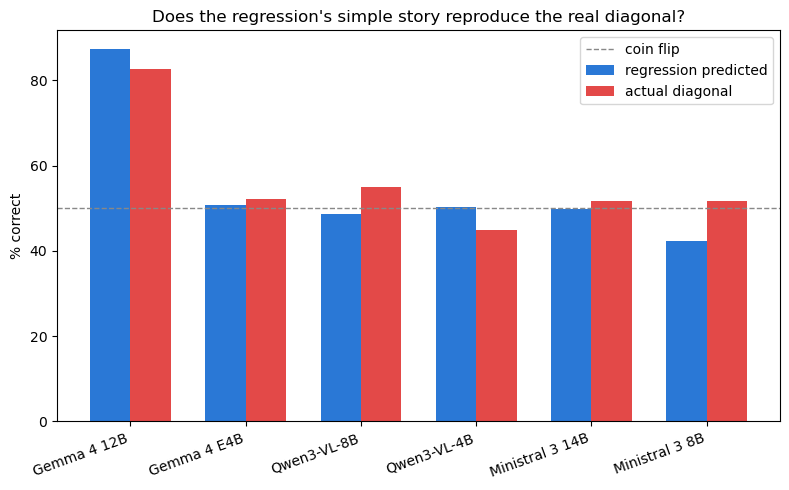

In [30]:
# sanity check (not including in thesis)
fig, ax = plt.subplots(figsize=(8, 5))
x = np.arange(len(claim2_metrics))
width = 0.35

def diagonal_accuracy(slug, condition):
    """% of diagonal trials (correct_scale == incorrect_scale) where the correct
    post was chosen. Reuses load_paired_grid, already defined above."""
    grid = load_paired_grid(slug, condition)
    correct = sum(sum(grid.get((s, s), [])) for s in SCALES)
    total = sum(len(grid.get((s, s), [])) for s in SCALES)
    return 100 * correct / total if total else float("nan")

real_diag = pd.Series(
    {label: diagonal_accuracy(slug, "metrics") for label, slug in ROSTER}
)

real_diag_aligned = claim2_metrics["model"].map(real_diag)

ax.bar(x - width/2, claim2_metrics["predicted_diagonal_pct"], width,
       label="regression predicted", color="#2a78d6")
ax.bar(x + width/2, real_diag, width, label="actual diagonal", color="#e34948")
ax.axhline(50, color="#888888", ls="--", lw=1, label="coin flip")
ax.set_xticks(x)
ax.set_xticklabels(claim2_metrics["model"], rotation=20, ha="right")
ax.set_ylabel("% correct")
ax.set_title("Does the regression's simple story reproduce the real diagonal?")
ax.legend()
plt.tight_layout()
plt.show()